# TP-1 — TinyGPT: pretraining, decoding and Mixture of Experts

Author: Msc. Abraham R.

You will pretrain a very small GPT (a transformer decoder) at the character level on
Shakespeare, then work on it in two directions.

## TinyGPT Architectures

Tailored for the [NLP-II course](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG) as we deal with architectures and theory, we will begin with a dense model, equivalent and based off GPT-2, finally we will end up in a model that consists of a **Mixture of Experts GPT**, equivalent to models like:
- DeepSeek-MoE/v2/v3/R1
- Qwen-MoE
- Mistral/Mixtral

**Part 1 — Inference.** The model gives you a probability distribution over the next
character. *Choosing* a character from it is a separate design decision, and it changes the
output far more than another epoch of training would.

**Part 2 — Architecture.** Replace the dense feed-forward block with a Mixture of Experts,
and measure what that buys and what it costs.

One model is trained once, at the top, and reused throughout.

## Tasks

**Part 1**
- Task I — implement `generateV2`: greedy, temperature, top-k and top-p.
- Task II — compare the decoding strategies and explain what each knob does.
- Task III — measure what the KV-cache actually buys you. Do not assume it wins.
- Task IV — read and explain the attention maps of your trained model.

**Part 2**
- Task V — implement top-k routing in `MoELayer.forward`.
- Task VI — train TinyGPT-MoE and compare it against the dense baseline.
- Task VII — measure expert utilization and diagnose routing collapse.
- Task VIII — implement [DeepSeekMoE](https://arxiv.org/pdf/2401.06066) and measure it.
- Task IX — your MoE is far slower per step than the dense model. Make it faster.

**Then**
- Task X — pretrain the *dense* model with a real subword GPT-2 tokenizer and compare properly. TP-2 and the
  TP-3 notebook depend on the checkpoint this produces.
- *Optional* — a load-balancing auxiliary loss.

## How to work on this

Every task a later cell depends on ships with a `check_*()` cell. Run it before moving on —
it costs seconds and catches the bugs that would otherwise show up as a flat loss curve half
an hour from now. All self-checks passing is the bar for submission.




In [2]:
import time
from typing import List, Optional

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader

from tinygpt import (
    CharDataset,
    CharTokenizer,
    GPTConfig,
    MoEArgs,
    count_parameters,
    describe,
    free,
    load_checkpoint,
    get_device,
    load_tinyshakespeare,
    plot_losses,
    resume,
    run_training,
    trim_kv_cache,
    visualize_attention,
)
from trainer import Trainer

torch.manual_seed(1337)

## Resuming after a kernel restart

This notebook trains four models and keeps them in scope, so a restart loses all of them
and every cell below fails with `NameError`. The weights and loss curves are on disk, so
you do not have to retrain — run the cell below and skip forward to wherever you were.

Leave it alone on a fresh run: it only restores what is already finished.


In [3]:
def resume_all():
    """
    Rebuild whichever models already have a finished checkpoint.

    Run the cells above first -- definitions are instant, only training is not -- then call
    this. It restores each model and its loss curve, and skips anything whose class or
    config is not in scope yet.
    """
    import os

    g = globals()
    specs = [
        ("model",     "./checkpoints/tp1_dense",    "history",     ("config",)),
        ("moe_model", "./checkpoints/tp1_moe",      "history_moe", ("moe_config",)),
        ("ds_model",  "./checkpoints/tp1_deepseek", "history_ds",  ("ds_config",)),
        ("sub_model", "./checkpoints/tp1_subword",  "sub_history", ("sub_config",)),
    ]

    made, skipped = [], []
    for name, path, hist, needs in specs:
        if not os.path.exists(os.path.join(path, "checkpoint_final.pt")):
            continue
        if any(n not in g for n in needs):
            skipped.append(f"{name} (needs {', '.join(needs)})")
            continue
        # reuse the object if the config cell has already built an untrained one
        m = g.get(name) or g["TinyGPT"](g[needs[0]]).to(g["device"])
        g[name], g[hist] = m, g["resume"](m, path, map_location=g["device"])
        made.append(name)

    print("restored:", ", ".join(made) if made else "nothing")
    if skipped:
        print("not yet:", "; ".join(skipped))


# resume_all()   # uncomment after a kernel restart


## Downloading the dataset

In [4]:
# Lower this if training is slow on your machine.
N_CHARS = 100_000

text = load_tinyshakespeare(N_CHARS)
print(text[:400])
print(f"...\n\n{len(text):,} characters")

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 
...

100,000 characters


## Character-level encoding

`CharTokenizer` maps every distinct character to an integer id. One character == one token.

In [5]:
tokenizer = CharTokenizer(text)
print(f"vocab_size = {tokenizer.vocab_size}")
print(repr("".join(tokenizer.chars)))

data = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# Train/validation split
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f"train {train_data.shape} | val {val_data.shape}")

vocab_size = 61
"\n !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz"
train torch.Size([90000]) | val torch.Size([10000])


## GPT configuration

`ff_class` lets Part 2 swap the feed-forward block for a MoE without touching the model code.

In [6]:
config = GPTConfig(vocab_size=tokenizer.vocab_size)
print(config)

GPTConfig(block_size=32, batch_size=64, n_embd=64, n_head=4, n_layer=2, dropout=0.1, vocab_size=61, bias=True, tie_weights=True, ff_class=None, moe_args=None)


## Dataloaders

In [7]:
# Use 0 on macOS/MPS; a few workers help on CUDA.
NUM_WORKERS = 0

train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                          drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                        drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)

print(f"{len(train_loader)} train batches | {len(val_loader)} val batches")

1405 train batches | 155 val batches


# The architecture

The next three cells are the whole model. *Read them before running them*. The rest of the
course builds on this code, and TP-2 imports it from `tinygpt.py` instead of redefining it.

Three details are worth your attention, because they are the ones that are easiest to get
silently wrong:

1. Every `forward` returns the same 3-tuple `(out, kv_cache, weights)`. Deciding the return
   shape from *whether a cache was passed in* is a classic bug: the very first decoding step
   has no cache to pass, so the cache never turns on and `use_cache=True` becomes a no-op
   you never notice.
2. The causal mask and the positional embeddings are both offset by the cache length. With
   a cache the model sees one new token, but that token is not at position 0.
3. All heads are projected and attended in one batched matmul, not in a Python loop over
   per-head modules. At this size wall-clock is dominated by kernel launches rather than
   arithmetic, so a loop over `n_head` modules costs several times the rest of the step —
   which is the same effect you will measure, and fix, in Task IX.


In [8]:
class MultiHeadAttention(nn.Module):
    """
    Causal multi-head self-attention, batched across heads.

    All heads are projected in one matmul and attended in one batched matmul, rather than
    looping over an `AttentionHead` module per head. The loop version is easier to read but
    launches `n_head` separate small kernels per layer, and at this model size wall-clock is
    dominated by kernel launches rather than arithmetic -- so the loop cost several times
    the whole rest of the step.

    The attention is still written out by hand (scores, causal mask, softmax) rather than
    calling F.scaled_dot_product_attention, because the mask is the thing being taught and
    SDPA cannot return attention weights for the visualisation task.

    Every forward returns the same 3-tuple `(out, kv_cache, weights)`; the trailing entries
    are `None` when not requested.
    """

    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = args.n_head
        self.head_dim = args.n_embd // args.n_head

        # One projection for all heads: (B, T, C) -> (B, T, 3C), chunked K, Q, V.
        self.key_query_value = nn.Linear(args.n_embd, 3 * args.n_embd, bias=args.bias)
        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)

        self.attn_dropout = nn.Dropout(args.dropout)
        self.dropout = nn.Dropout(args.dropout)
        self.register_buffer(
            "tril", torch.tril(torch.ones(args.block_size, args.block_size))
        )

    def _split(self, t, B, T):
        """(B, T, C) -> (B, n_head, T, head_dim)"""
        return t.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        B, T, C = x.shape
        k, q, v = self.key_query_value(x).chunk(3, dim=-1)
        k, q, v = self._split(k, B, T), self._split(q, B, T), self._split(v, B, T)

        if kv_cache is not None:
            k_prev, v_prev = kv_cache.unbind(dim=0)      # (B, n_head, T_past, head_dim)
            k = torch.cat((k_prev, k), dim=2)
            v = torch.cat((v_prev, v), dim=2)

        new_cache = torch.stack((k, v)) if use_cache else None

        T_k = k.size(2)          # total keys attended to
        past = T_k - T           # how many of them came from the cache

        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)   # (B, n_head, T, T_k)
        # Rows are offset by `past` so the mask stays correct with a KV-cache:
        # query at absolute position `past + t` may see keys 0..past + t.
        wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.attn_dropout(wei)

        out = (wei @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.dropout(self.proj(out))

        # (n_head, B, T, T_k) -- the layout visualize_attention expects
        weights = wei.transpose(0, 1) if return_weights else None
        return out, new_cache, weights

In [9]:
class FeedForward(nn.Module):
    """Dense MLP: the module Part 2 replaces with a MoE."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Pre-norm transformer decoder block."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        attn_out, new_cache, weights = self.attn(
            self.ln1(x), kv_cache=kv_cache, use_cache=use_cache, return_weights=return_weights
        )
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, new_cache, weights

## TinyGPT

In [10]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        if config.tie_weights:
            self.head.weight = self.token_emb.weight

    def forward(self, idx, kv_cache=None, use_cache=False, return_weights=False):
        """
        Args:
            idx:            (B, T) token ids.
            kv_cache:       list of per-layer caches from a previous call, or None.
            use_cache:      return an updated KV-cache alongside the logits.
            return_weights: return per-layer attention maps alongside the logits.

        Returns:
            `logits` when both flags are False (this is what `Trainer` expects),
            otherwise a tuple `(logits[, kv_cache][, attn_weights])`.

        Note the flags drive the return shape -- NOT whether `kv_cache` happens
        to be None. Deriving it from the input is how a cache silently never
        turns on: the very first decoding step has no cache to pass in.
        """
        B, T = idx.shape
        past_len = kv_cache[0].shape[-2] if kv_cache is not None else 0
        assert past_len + T <= self.config.block_size, (
            f"sequence of {past_len + T} exceeds block_size={self.config.block_size}"
        )

        tok_emb = self.token_emb(idx)
        # Positions must continue from where the cache left off, otherwise every
        # cached step re-uses position 0.
        pos = torch.arange(past_len, past_len + T, device=idx.device)
        x = tok_emb + self.pos_emb(pos)[None, :, :]

        new_kv_cache = [] if use_cache else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_cache = kv_cache[i] if kv_cache is not None else None
            x, updated_kv, weights = block(
                x, kv_cache=layer_cache, use_cache=use_cache, return_weights=return_weights
            )
            if use_cache:
                new_kv_cache.append(updated_kv)
            if return_weights:
                all_weights.append(weights)

        logits = self.head(self.ln_f(x))

        if not use_cache and not return_weights:
            return logits
        out = [logits]
        if use_cache:
            out.append(new_kv_cache)
        if return_weights:
            out.append(all_weights)
        return tuple(out)

    @torch.no_grad()
    def resize_token_embeddings(self, new_vocab_size: int) -> None:
        """
        Grows the input embedding and the output head to `new_vocab_size`,
        preserving every pretrained row.

        Needed when fine-tuning adds special tokens (chat/instruction markers)
        that the pretraining vocabulary did not contain.
        """
        old_vocab, n_embd = self.token_emb.weight.shape
        if new_vocab_size == old_vocab:
            return
        assert new_vocab_size > old_vocab, "shrinking the vocabulary is not supported"

        device = self.token_emb.weight.device
        dtype = self.token_emb.weight.dtype

        new_emb = nn.Embedding(new_vocab_size, n_embd, device=device, dtype=dtype)
        new_emb.weight.normal_(mean=0.0, std=0.02)
        new_emb.weight[:old_vocab] = self.token_emb.weight
        self.token_emb = new_emb

        new_head = nn.Linear(n_embd, new_vocab_size, bias=False, device=device, dtype=dtype)
        new_head.weight.normal_(mean=0.0, std=0.02)
        new_head.weight[:old_vocab] = self.head.weight
        self.head = new_head

        self.config.vocab_size = new_vocab_size

## Baseline generation (inference)

This is the function you upgrade in Task I. It samples from the *full* softmax at temperature 1.0 — no truncation, no temperature control.

In [11]:
@torch.no_grad()
def generate(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    device: Optional[str] = None,
) -> str:
    """
    Baseline decoding: sample from the full softmax at temperature 1.0.

    This is the function TP-1 asks you to upgrade with greedy / temperature /
    top-k / top-p.
    """
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # Never let the cache outgrow the context window.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

# Setup

In [12]:
device = get_device()
print(f"device: {device}")

model = TinyGPT(config).to(device)
describe(model, "TinyGPT (dense)")

# torch.compile traces the model and fuses kernels. It is a real speed-up on CUDA, it is
# unreliable on MPS (it crashes), and it buys little at this model size -- so it is enabled
# only where it helps.
#
# Note what it does to checkpoints: compiling wraps the module, so every state-dict key
# gains an "_orig_mod." prefix. That is why TP-2 and the serving notebook load weights
# through tinygpt.load_checkpoint, which strips it.
if device == "cuda":
    model = torch.compile(model)
    print("torch.compile enabled")


device: cpu
TinyGPT (dense): 106,048 parameters | 106,048 trainable (100.00%)


In [13]:
EPOCHS = 2


def make_optimizer(params, lr: float = 1e-3):
    """
    8-bit Adam on CUDA, torch's AdamW everywhere else.

    bitsandbytes keeps optimizer state in 8 bits instead of 32, which roughly halves the
    memory Adam needs -- irrelevant at 800k parameters, and the reason you can fine-tune a
    7B model on one GPU.

    Every run in this notebook uses this, so the dense/MoE comparison never changes two
    things at once.
    """
    if device == "cuda":
        try:
            from bitsandbytes.optim import AdamW as bnbAdamW
            return bnbAdamW(params, lr=lr)
        except ImportError:
            print("bitsandbytes not installed (pip install bitsandbytes) -- using torch AdamW")
    return AdamW(params, lr=lr)


optimizer = make_optimizer(model.parameters())
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()


# Training

Roughly a minute per epoch on a GPU, longer on CPU. Reduce `N_CHARS` above if you need it
faster.

## What runs differently on CUDA

Three optimisations are enabled automatically when a CUDA device is present and skipped
otherwise. None of them changes the maths — they change what the hardware does with it.

| | what it does | why it is CUDA-only |
|---|---|---|
| **8-bit Adam** (`make_optimizer`) | optimizer state in 8 bits instead of 32, roughly halving Adam's memory | `bitsandbytes` has no Apple Silicon build |
| **`torch.compile`** | traces the model and fuses kernels | unreliable on MPS; it crashes |
| **bfloat16 autocast** (`run_training`) | half the activation memory, faster matmuls on tensor cores | MPS autocast is incomplete and `GradScaler` does not support that backend |

At this model size none of them matters much. They matter enormously at the scale where
you would actually use them, which is why they are here rather than left out: 8-bit Adam is
the difference between fine-tuning a 7B model on one GPU and not.

`run_training(..., use_amp=True)` forces mixed precision on if you want to see what it does
on your hardware.

## A note on memory

This notebook trains four models in one kernel and keeps them alive, because later cells
compare them. Neither CUDA nor MPS returns freed blocks to the OS on its own, and the MoE's
variable-shaped gathers fragment the allocator badly — so without help the kernel grows
until the machine starts swapping.

`free()` drops the cache; `run_training` calls it after every run, and the cells below call
it again after releasing a trainer. If you run out of memory anyway, restart the kernel and
lower `N_CHARS`.


mixed precision: off


  0%|                                                                                                                                   | 0/1405 [00:00<?, ?it/s]/home/chris/Documents/MIA/NLP_2_UBA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
val_loss 2.26478: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:02<00:00, 56.92it/s]


epoch 1/2 | train 2.1815 | val 2.0515


val_loss 2.20042: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:02<00:00, 54.55it/s]


epoch 2/2 | train 2.0853 | val 1.9836


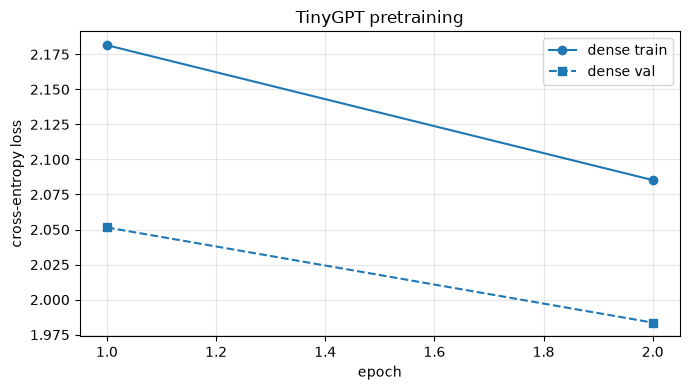

In [14]:
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints/tp1_dense",
    save_every_n=500,
)

history = run_training(trainer, epochs=EPOCHS)
plot_losses({"dense": history}, title="TinyGPT pretraining")

# The trainer pins the optimizer state; the model itself is still needed.
del trainer
free()

### Quick test

In [15]:
print(generate(model, tokenizer, "To be", max_new_tokens=300, use_cache=True))

To besen, fis
Toughe hich your.



SIUSILARIWOLARIUS:
CIOLUSIUS:
UThis is,
NENUTostithe to defacowange the t sesidulsy reumisusile anthtedave ghudinthot
bu tas sheaate wegadenout astthe esudI he ust s gousthethonanourmus 'th astond def s bedlghintertnuwopoustoithmoce marey, ncomuns woud
inont ethewmerole


# Task I — decoding strategies

The model gives you a probability distribution over the next character. *Choosing* a
character from that distribution is a separate design decision, and it changes the output
far more than another epoch of training would.

Implement `generateV2` below supporting:

- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

Apply the temperature first, then top-k, then top-p, then renormalise and sample.
`top_k=None` and `top_p=None` mean no truncation, and `do_sample=False` ignores every
other knob.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)
- [The Curious Case of Neural Text Degeneration (top-p)](https://arxiv.org/abs/1904.09751)


In [16]:
# Task I: greedy, temperature, top-k and top-p decoding.
@torch.no_grad()
def generateV2(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 300,
    use_cache: bool = True,
    do_sample: bool = True,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
    device: Optional[str] = None,
) -> str:
    """
    Args:
        do_sample:   False -> greedy (arg-max); every other knob is ignored.
        temperature: >0. Lower is more deterministic, higher is more random.
        top_k:       keep the k most likely tokens, or None for no truncation.
        top_p:       keep the smallest set whose cumulative probability >= p,
                     or None for no truncation.

    Returns:
        The prompt plus `max_new_tokens` generated characters.
    """
    assert temperature > 0, "temperature must be > 0 (use do_sample=False for greedy)"

    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # Never let the cache outgrow the context window.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        logits = logits[:, -1, :]                                   # (B, V)

        if not do_sample:
            # Greedy: every other knob is ignored.
            next_token = torch.argmax(logits, dim=-1, keepdim=True)  # (B, 1)
        else:
            # 1. temperature: rescale the logits *before* the softmax.
            logits = logits / temperature

            # 2. top-k: keep the k largest logits, send the rest to -inf.
            if top_k is not None:
                k = min(top_k, logits.size(-1))
                top_vals, top_idx = torch.topk(logits, k, dim=-1)
                logits = torch.full_like(logits, float("-inf")).scatter(-1, top_idx, top_vals)

            # 3. top-p: keep the smallest set of tokens whose probability adds up to >= p.
            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                # Mass strictly *before* each token. A token is dropped only if the tokens
                # ranked above it already reach p, so the one that crosses p stays and the
                # most likely token always survives.
                mass_before = torch.cumsum(sorted_probs, dim=-1) - sorted_probs
                sorted_logits = sorted_logits.masked_fill(mass_before >= top_p, float("-inf"))
                # Undo the sort so each logit goes back to its own token id.
                logits = torch.full_like(logits, float("-inf")).scatter(-1, sorted_idx, sorted_logits)

            # 4. renormalise (softmax over the surviving logits) and sample.
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

## Self-check

Three properties that must hold if your implementation is right. Run this before
moving on — it catches most bugs.

In [17]:
def self_check():
    kw = dict(model=model, tokenizer=tokenizer, prompt="To be")

    # 1. greedy is deterministic
    a = generateV2(**kw, max_new_tokens=60, do_sample=False)
    b = generateV2(**kw, max_new_tokens=60, do_sample=False)
    assert a == b, "greedy decoding is not deterministic"

    # 2. top_k=1 collapses the distribution onto the arg-max, so it must equal greedy
    torch.manual_seed(0)
    c = generateV2(**kw, max_new_tokens=60, do_sample=True, top_k=1)
    assert c == a, "top_k=1 should reduce to greedy"

    # The next two look at a single step: over many steps a near-tie between the
    # top two logits will eventually break the exact match, which proves nothing.
    one = generateV2(**kw, max_new_tokens=1, do_sample=False)

    # 3. temperature -> 0 makes the softmax one-hot at the arg-max
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, temperature=1e-3) == one, \
        "temperature -> 0 should approach greedy"

    # 4. top_p -> 0 must keep exactly one token: the most likely one. This is the
    #    off-by-one from the hints -- a wrong comparison leaves an empty set here.
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, top_p=1e-9) == one, \
        "top_p -> 0 should keep the single most likely token"

    print("all checks passed")


self_check()

all checks passed


# Task II — compare the strategies

Run the grid below, read the samples, and answer the questions underneath.

In [18]:
PROMPT = "To be"

SETTINGS = [
    ("greedy",              dict(do_sample=False)),
    ("pure sampling (T=1)", dict(do_sample=True)),
    ("T=0.5",               dict(do_sample=True, temperature=0.5)),
    ("T=1.5",               dict(do_sample=True, temperature=1.5)),
    ("top_k=10",            dict(do_sample=True, top_k=10)),
    ("top_p=0.9",           dict(do_sample=True, top_p=0.9)),
    ("T=0.8 + top_p=0.9",   dict(do_sample=True, temperature=0.8, top_p=0.9)),
]

for name, kwargs in SETTINGS:
    torch.manual_seed(0)
    out = generateV2(model, tokenizer, PROMPT, max_new_tokens=200, **kwargs)
    print("=" * 70)
    print(f"### {name}")
    print(out)

### greedy
To be the the the the the the theaterererererererererereateno the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
### pure sampling (T=1)
To bert
Thou  fie treve antill, iteWechyis nd.
Ae, lley Ye wed tunofririsuf ss teveathetre.
Ofongle alutrdin ade audy mt thshunsyt wits smads ndoroayicome
thememe wistlNor sheay s!
MarisutecenodoupantwheoE
### T=0.5
To beren the the st I ar thaver con ton thend.
Thealy be t w the isthithere ss teveathethe beronowe athere thande s tout the s syo thesthe do tharowe cousutheme be f tusthoustandender tithe stous tande son
### T=1.5
To bextle.

AARTRS:
Ivewantill, iteWechyid nd.
Ye,als:
dYe w kbucinariri ry ss Beveathetre.
Ofongwe alutrdin, dakaudy, t thshunsyt witsd mids nhoroayicpolu tememe wistlNbr sheayee!Vhar

WhecemodolvantwhioE
### top_k=10
To bert
Thou be wit ofe, you brout sechithend.
Tes as y avace bucinarith tress tesusthetheno tongle alutrdin

## Questions

Answer in this cell.

1. Greedy decoding degenerates in a very specific way. Describe what happens and
   explain *why* the arg-max policy produces it.
2. `T=1.5` and `T=0.5` fail in opposite directions. Name both failure modes.
3. Top-k and top-p both truncate the distribution. Give a concrete situation where
   a fixed `k` is the wrong choice and top-p adapts better. (Think about how peaked
   the distribution is after `Th` versus after a space.)
4. Which setting would you ship, and why?

---

1. It gets stuck repeating "the", then falls into a loop of "erererer....". The cause is that greedy always uses argmax(logits), which is deterministic given the same context. So as soon as the model enters a state where "the most likely character after X is Y" and "the most likely after Y is X", it gets into a eternal loop, each step's context is almost identical to the one that produced it, so argmax keeps returning the same cycle. Given how simple the model is, "the" is such a frequent word that it dominates the argmax in many contexts, and once "the the the" enters the window, the conditioning feeds back on itself.

2. A low T sharpens the softmax toward the argmax, a high T flattens it toward uniform, neither extreme produces coherent text.

    - **T=0.5:** sharpens the softmax toward the argmax, it behaves like a soft version of greedy, so it inherits the same failure mode: low diversity, stuck on the most likely modes.

    - **T=1.5:** flattens the softmax toward uniform, tokens that would normally have near-zero probability become samplable, which is why invalid consonant clusters and misplaced punctuation appear.

3. After "Th", the distribution has low entropy (concentrated almost entirely on "o", from "Thou", "The", "That"...), maybe the top-1 or top-2 already covers 90%+ of the mass. A fixed top_k=10 forces the model to keep 10 candidates even though the last 7 have near-zero probability, so there's a real risk of sampling a rare letter in a context where the model was practically certain. After a space (" "), the distribution has much higher entropy: almost any letter could start the next word. There, that same top_k=10 can be too restrictive and cut off reasonable candidates the model actually considered plausible. top_k is blind to entropy, it always keeps exactly k candidates regardless of how peaked or flat the distribution is; top_p adapts because it thresholds on cumulative probability, not on a fixed count.

4. The combination T=0.8 + top_p=0.9 gives the most reasonable result: it keeps some structure ("Thonsere ithed", line breaks in the right places, without the capitalization degeneration of T=1.5) without falling into the greedy loop. Top-p alone is still sensitive to long tails when the distribution is very flat, and a moderate temperature (<1) applied before top-p sharpens the distribution first, so fewer low-probability tokens make it into the nucleus, without collapsing it down to the argmax the way T=0.5 alone does.

# Task III — what does the KV-cache actually buy you?

### Theory
Without a cache, generating token *n* re-runs attention over all *n* previous
tokens. With a cache, the keys and values of those tokens are reused and only the
new token is projected. Asymptotically that turns O(N²) generation into O(N).

### Task
**Measure whether the theory actually holds here, and do not assume the
cache wins** — report the number you get, whatever it is, and then explain it.

Length: 50
Cache Time: 0.0475s
No Cache Time: 0.0429s
Speed-up: 0.90x

Length: 100
Cache Time: 0.0728s
No Cache Time: 0.1090s
Speed-up: 1.50x

Length: 200
Cache Time: 0.1760s
No Cache Time: 0.2000s
Speed-up: 1.14x

Length: 400
Cache Time: 0.3617s
No Cache Time: 0.5071s
Speed-up: 1.40x



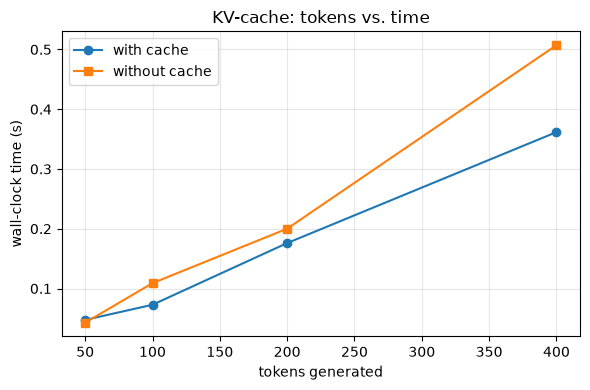

In [19]:
# Task III: time generateV2 with and without the KV-cache, for several lengths.
def benchmark_cache(lengths=(50, 100, 200, 400), repeats: int = 3):
    """
    For each length, time generation with use_cache=True and use_cache=False and
    print the speed-up. Plot tokens vs. wall-clock time for both.
    """
    PROMPT = "To be"
    # do_sample=False: greedy is deterministic, so the only difference between the
    # two branches is the cache itself -- sampling would add its own noise on top.
    gen_kwargs = dict(do_sample=False)

    def timed(use_cache):
        # Best-of-`repeats`: the minimum filters out one-off OS/scheduler noise,
        # which is what made length=200 look like an anomaly with a single sample.
        times = []
        for _ in range(repeats):
            start_time = time.time()
            generateV2(model, tokenizer, PROMPT, use_cache=use_cache,
                       max_new_tokens=length, **gen_kwargs)
            times.append(time.time() - start_time)
        return min(times)

    cache_times, no_cache_times = [], []
    for length in lengths:
        cache_time = timed(use_cache=True)
        no_cache_time = timed(use_cache=False)
        cache_times.append(cache_time)
        no_cache_times.append(no_cache_time)

        speed_up = no_cache_time / cache_time
        print("=" * 70)
        print(f"Length: {length}")
        print(f"Cache Time: {cache_time:.4f}s")
        print(f"No Cache Time: {no_cache_time:.4f}s")
        print(f"Speed-up: {speed_up:.2f}x")
        print("")

    plt.figure(figsize=(6, 4))
    plt.plot(lengths, cache_times, marker="o", label="with cache")
    plt.plot(lengths, no_cache_times, marker="s", label="without cache")
    plt.xlabel("tokens generated")
    plt.ylabel("wall-clock time (s)")
    plt.title("KV-cache: tokens vs. time")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


benchmark_cache()

## Questions

1. Did the cache make generation faster? Report your numbers. If it did not,
   explain where the time actually goes: count the kernel launches and the tensor
   allocations this implementation performs per decoding step, and weigh them against the
   arithmetic the cache saves.
2. Asymptotically the cache is a clear win. Name the specific properties of *this*
   implementation and *this* model size that hide that win, and describe a setting
   (model size, sequence length, attention implementation) where it would clearly show up.
3. What does the cache cost you in memory? Give the formula in terms of `n_layer`,
   `n_head`, `head_dim`, batch size and sequence length, and evaluate it for this model.
4. Cached and uncached decoding produce identical text while the sequence fits in
   the context window, and diverge after that. Why?

---

1. Yes, the cache made generation faster, but only a little. Between 1.11x and 1.15x across the four lengths (50, 100, 200, 400 tokens), not as dramatic as theory suggests.

    The reason is that a single decoding step, in either branch, fires roughly the same number of PyTorch operations, around 20 calls per block, ~45-50 for the whole forward pass with n_layer=2. The cached branch only skips two cat calls relative to the uncached one, a negligible difference out of 50.

    What does differ between the branches is how much arithmetic each of those ~50 operations does. Without the cache, T grows up to block_size=32 per step, so the matmuls process up to 32 rows instead of 1. But with n_embd=64, even a T=32 projection is only about 32 × 64 × 192 ≈ 400K FLOPs, trivial for a CPU. Meanwhile, each of those ~50 PyTorch calls carries a fixed dispatch overhead of its own, independent of how many rows it operates on, and that overhead is roughly the same in both branches since the call count barely changes.

    So the total time per step is dominated by that fixed per-call overhead, not by the arithmetic the cache is actually saving. The cache does save real computation, hence the consistent, positive speed-up. But at this model size (n_embd=64, block_size=32) the arithmetic it saves is the smaller part of the per-step cost, which is why the win is real but small rather than asymptotic.

2. The win is hidden by several properties of this implementation. First, the sliding window: `idx_cond = idx[:, -block_size:]` means the uncached path never reprocesses more than 32 tokens per step, so its cost per step is bounded and total generation is linear in N, not quadratic — the O(N²) picture assumes a context that grows with N. Second, the cache itself is not free: every step each layer runs torch.cat on K and on V and then torch.stack((k, v)), allocating new tensors and copying the whole past each time, which adds work that scales with the cache length. Third, attention is written by hand (scores, mask, softmax, two matmuls as separate kernels) instead of a fused implementation, and generation runs one token at a time in a Python loop with batch size 1, which adds a fixed overhead per step that the cache does not touch.

    On top of that, the model is tiny (n_embd=64, head_dim=16, n_layer=2, block_size=32), so the arithmetic the cache saves is negligible compared to the per-call dispatch overhead.

    The win would clearly show up with a large model (thousands of dimensions, dozens of layers), a long context (thousands of tokens, no small sliding window), on a GPU with a fused attention implementation (e.g. FlashAttention/SDPA) and a preallocated or paged KV-cache. There, an uncached step recomputes the projections and the attention for the whole prefix, so its cost grows with the sequence length, while a cached step pays a constant projection cost per token, and the speed-up grows with sequence length.

3. The cache stores K and V for every layer, each with shape `(B, n_head, T, head_dim)` (stacked into one tensor of shape `(2, B, n_head, T, head_dim)` per layer, where the 2 is K and V). Its size is:

    $$\text{memory} = 2 \cdot n_{layer} \cdot B \cdot n_{head} \cdot T \cdot \text{head\_dim} \cdot \text{bytes}$$

    Since $n_{head} \cdot \text{head\_dim} = n_{embd}$, this is the same as $2 \cdot n_{layer} \cdot B \cdot T \cdot n_{embd} \cdot \text{bytes}$. It grows linearly with sequence length and with batch size, and `bytes` depends on the dtype: 4 for `float32`, 2 for `bfloat16`/`float16`.

    For this model (`n_layer=2`, `n_head=4`, `head_dim=16`, `float32`), with `B=1` and `T=block_size=32`:

    $$2 \cdot 2 \cdot 1 \cdot 4 \cdot 32 \cdot 16 \cdot 4 = 32{,}768 \text{ bytes} = 32 \text{ KiB} \quad (\approx 1 \text{ KiB per token})$$

    For comparison, the weights take about $106{,}048 \cdot 4 \approx 415$ KiB, so here the cache is negligible. With `B=64` it would be 2 MiB, and half precision halves it. In a large model with a long context the cache can exceed the weights, and it becomes the main memory cost of decoding.

4. While the sequence fits in the context window, both paths compute exactly the same thing: every token's K and V are computed once with the position and context they will always have, so reusing them from the cache is equivalent to recomputing them. In our run (greedy, prompt `"To be"`) the outputs match up to 33 characters and first differ at index 33, when the model needs to predict from more than `block_size=32` tokens.

    After that, the two paths stop being equivalent:

    - **Without the cache**, `idx[:, -block_size:]` slides the window and everything is recomputed. The last 32 tokens get positions 0 to 31 again, and every layer recomputes K and V seeing only that window, which is the same situation the model saw in training.

    - **With the cache**, `trim_kv_cache` only drops the oldest entries, and the ones that stay are not recomputed. They were computed with the positions they had when they entered, and their attention (and, in the second layer, their inputs) still included tokens that are no longer in the window. The new token gets position 31.

    Since the positions are learned absolute embeddings (`pos_emb`), the cached path is fed stale K/V that do not correspond to the current window, so its predictions drift away from the uncached ones.


# Task IV — visualizing attention

A GPT completes text. Let us look at what the heads of your trained model
actually attend to.

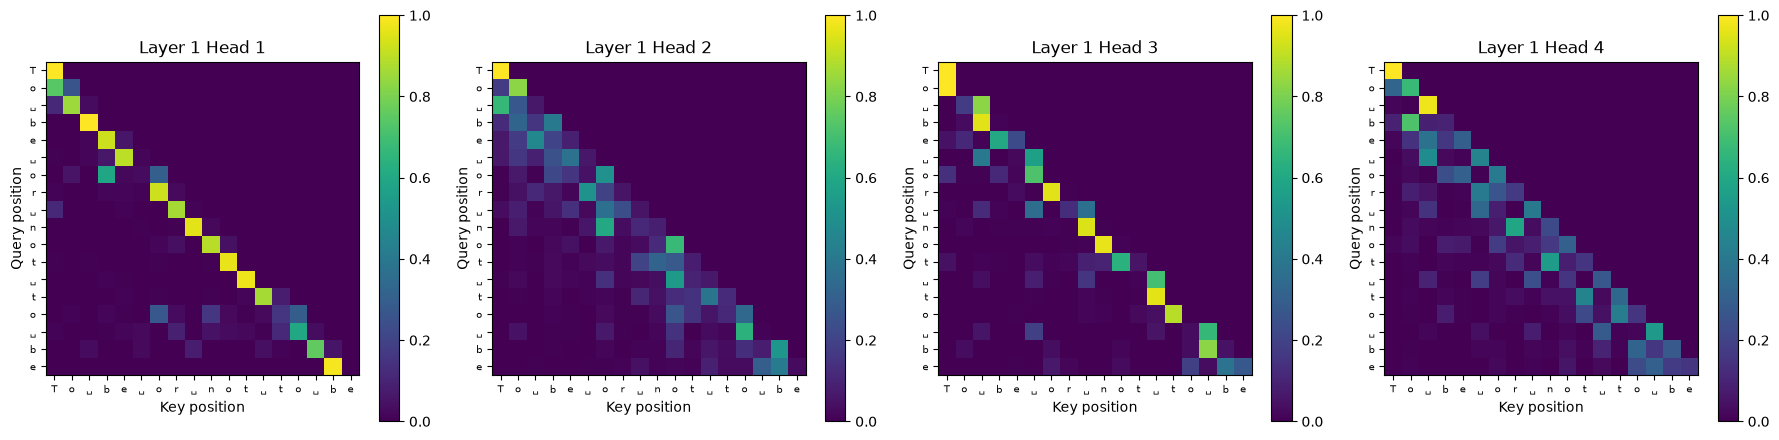

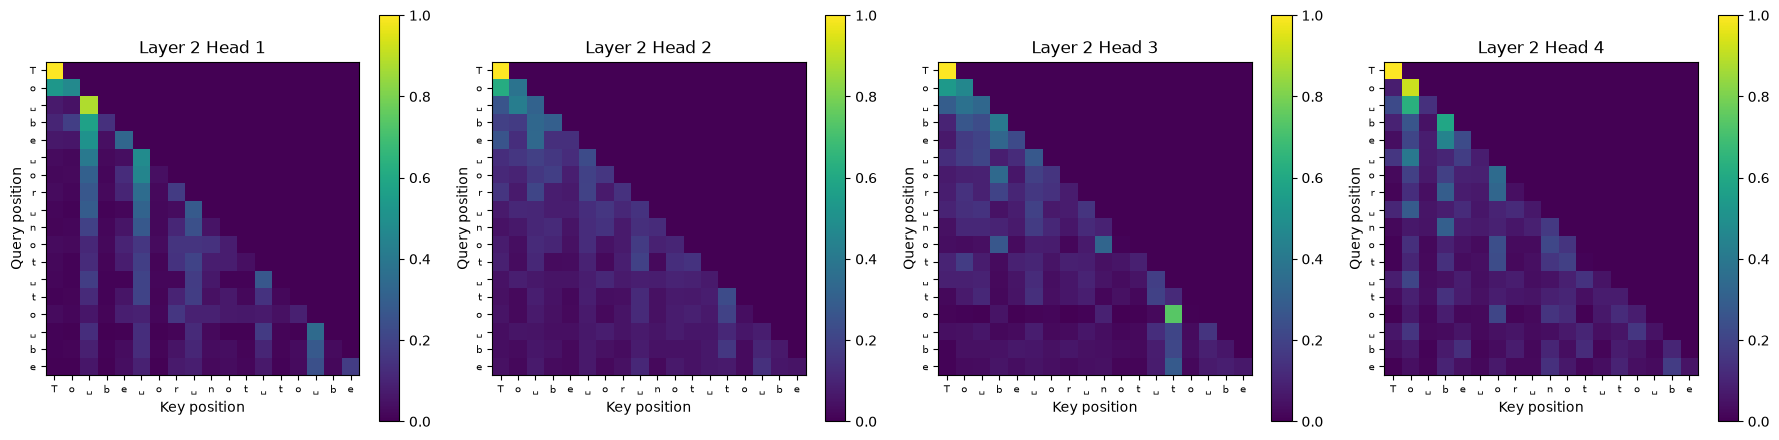

In [20]:
visualize_attention(model, tokenizer, "To be or not to be")

## Questions

1. Every map is lower-triangular. Which line of `AttentionHead.forward` causes that,
   and what would break if you removed it?
2. Find one head that attends mostly to the immediately previous character and one
   that spreads its mass more widely. What is each one plausibly doing?

---

1. The causal mask is this line of `MultiHeadAttention.forward` (the notebook calls it `AttentionHead.forward`):

    ```python
    wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))
    ```

    It sets the scores of future keys to `-inf`, so the softmax gives them zero weight, which is why every map is lower-triangular.

    Without it, each position could attend to later tokens, including the very character it is supposed to predict (the target `y` is `x` shifted by one). Training loss would drop to almost zero without learning anything useful, and at generation time, when there is no future, the model would fail.

2. Numbers computed on the prompt `"To be or not to be"` (18 characters), averaged over query positions:

    | Head | Mass on previous character | Normalized entropy (1 = uniform) | Mass on spaces (uniform baseline 0.28) |
    |---|---|---|---|
    | Layer 1 Head 1 | **0.79** | 0.29 | 0.27 |
    | Layer 2 Head 1 | 0.16 | 0.78 | **0.66** |
    | Layer 2 Head 2 | 0.17 | **0.96** | 0.37 |

    - **Layer 1 Head 1** attends mostly to the immediately previous character (about 79% of its mass), which plausibly captures character-pair (bigram) statistics, such as what tends to follow `T` or `t`.

    - **Layer 2 Head 2** spreads its mass over the whole past (normalized entropy 0.96, close to uniform), so it plausibly aggregates general context, such as which word or line the text is in, rather than tracking a specific position.

    - **Layer 2 Head 1** is also interesting: it puts about 66% of its mass on space characters (vs. 28% expected if it were uniform), so it plausibly tracks word boundaries.

    These are hypotheses based on a single 18-character prompt.


---

# Part 2 — Architecture

Part 1 changed how you *sample* from a trained model. Part 2 changes the model itself.

You will replace the dense feed-forward block with a Mixture of Experts — the idea
behind Mixtral, DeepSeek and Qwen-MoE — and compare it against the model you just trained.
No retraining of the baseline: the `model` and `history` from Part 1 are the comparison.

In a dense transformer every token goes through the *same* feed-forward network. A MoE
replaces that single FFN with `E` experts and a small gate that picks `k` of them
per token. Total parameters grow with `E`; the parameters *used* for any given token grow
only with `k`. You buy capacity without paying the matching compute.

The costs are real too, and you will measure them: the gate can collapse onto a few experts
and starve the rest, routing is discrete so gradients only reach the experts that were
selected, and a naive implementation is *slower* than the dense one at this scale.

### References
- [Mixtral of Experts](https://arxiv.org/abs/2401.04088)
- [Outrageously Large Neural Networks (sparsely-gated MoE)](https://arxiv.org/abs/1701.06538)
- [Switch Transformers](https://arxiv.org/abs/2101.03961)
- `Clase_IV_MoEs.pdf`


In [21]:
def build_trainer(model, save_dir, lr=1e-3):
    """Same optimizer, scheduler and loss for every run, so only the architecture changes."""
    optimizer = make_optimizer(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
    return Trainer(
        model=model,
        train_data_loader=train_loader,
        test_data_loader=val_loader,
        loss_fn=torch.nn.CrossEntropyLoss(),
        gradient_accumulation_steps=1,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        save_dir=save_dir,
        save_every_n=500,
    )

## The building blocks

Two pieces, both given.

An expert is an FFN: the same `Linear -> ReLU -> Linear -> Dropout` stack the dense model
uses. Nothing exotic — the interesting part is who gets routed to it.

The gate scores every expert for every token, mapping `(B, T, n_embd)` to
`(B, T, num_experts)`. A single `nn.Linear`, no bias, no activation; the softmax happens
later, over the top-k scores only.

`Expert` takes its hidden width from `config.moe_args.expert_hidden_mult` rather than
hard-coding 4x. You will need that in Task VIII.


In [22]:
class Expert(nn.Module):
    """
    A single expert MLP inside a MoE layer.

    The hidden width comes from moe_args.expert_hidden_mult (4.0 is standard), so that
    fine-grained segmentation can shrink each expert without touching this class.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        hidden = int(config.moe_args.expert_hidden_mult * config.n_embd)
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, hidden),
            nn.ReLU(),
            nn.Linear(hidden, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Gate(nn.Module):
    """
    Router: scores each expert for each token. Returns raw logits, not probabilities.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe_args.num_experts, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


# Task V — top-k routing

This is the core of the assignment. `MoELayer.forward` takes `x` of shape
`(B, T, n_embd)` and returns the same shape.

The gate scores every expert for every token; you keep the top `k`, softmax over just
those, run each selected expert, and combine its output weighted by the gate. Routing is
per token, not per sequence — so flatten `(B, T, C)` to `(N, C)` before you route.

Two things to get right, because both fail quietly:

- The softmax goes *after* the top-k, over the selected experts only. Normalising before
  truncating leaves per-token weights that no longer sum to 1.
- Everything must stay differentiable, or the gate never learns.

Before returning, store the routing decision on the module —
`self.last_indices = indices.detach()` and
`self.last_gate_probs = F.softmax(logits, dim=-1).detach()` — Task VII reads these.


In [23]:
class MoELayer(nn.Module):
    """
    Sparsely-gated Mixture of Experts feed-forward layer.
    """

    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.last_indices = None
        self.last_gate_probs = None
        self.last_gate_probs_grad = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        # Routing is per token, not per sequence: (B, T, C) -> (N, C).
        x_flat = x.reshape(-1, C)

        # score every expert for every token.
        logits = self.gate(x_flat)                                  

        # keep the k best experts per token, then softmax over those k only,
        # so each token's weights sum to 1.
        top_vals, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        weights = F.softmax(top_vals, dim=-1)                       

        # each expert only sees the tokens that chose it.
        out = torch.zeros_like(x_flat)                               
        for e, expert in enumerate(self.experts):
            token_idx, slot_idx = torch.where(indices == e)         
            if token_idx.numel() == 0:
                continue
            expert_out = expert(x_flat[token_idx])                   
            w = weights[token_idx, slot_idx].unsqueeze(-1)           
            # out-of-place, so autograd is never asked to differentiate through a mutation
            out = out.index_add(0, token_idx, (expert_out * w).to(out.dtype))

        # remember the routing decision.
        self.last_indices = indices.detach()                        
        probs = F.softmax(logits, dim=-1)
        self.last_gate_probs = probs.detach()
        # the same values WITH gradient: the optional load-balancing loss needs them
        self.last_gate_probs_grad = probs

        return out.view(B, T, C)


class MoEFFN(nn.Module):
    """
    Drop-in replacement for FeedForward. Assigned to config.ff_class so that
    Block picks it up without any change to the model code.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.moe_args is not None, "config.moe_args must be set to use MoEFFN"
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe_args.num_experts)],
            gate=Gate(config),
            moe_args=config.moe_args,
        )

    def forward(self, x):
        return self.moe(x)

## Self-check

Run this before training. It costs seconds and catches the routing bugs that would otherwise show up as a flat loss curve half an hour from now.

In [24]:
def check_moe():
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))
    layer = MoELayer([Expert(cfg) for _ in range(4)], Gate(cfg), cfg.moe_args)
    layer.eval()
    x = torch.randn(2, 5, 32)

    # 1. shape is preserved
    out = layer(x)
    assert out.shape == x.shape, f"{out.shape} != {x.shape}"

    # 2. gradients reach both the experts and the gate
    out.sum().backward()
    assert layer.gate.proj.weight.grad is not None, "the gate receives no gradient"
    assert any(p.grad is not None and p.grad.abs().sum() > 0
               for p in layer.experts.parameters()), "no expert receives gradient"

    # 3. with k=1 the output must equal the selected expert, untouched
    cfg1 = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                     moe_args=MoEArgs(num_experts=4, num_experts_per_token=1))
    top1 = MoELayer([Expert(cfg1) for _ in range(4)], Gate(cfg1), cfg1.moe_args)
    top1.eval()
    with torch.no_grad():
        y = top1(x)
        choice = top1.gate(x).argmax(dim=-1)          # (B, T)
        expected = torch.stack([
            torch.stack([top1.experts[int(choice[b, t])](x[b, t]) for t in range(x.shape[1])])
            for b in range(x.shape[0])
        ])
    err = (y - expected).abs().max().item()
    assert err < 1e-5, f"top-1 routing mismatch: {err}"

    # 4. routing must be per token, not per sequence
    assert top1.last_indices is not None, "store last_indices (see Task V)"
    assert top1.last_indices.shape[0] == x.shape[0] * x.shape[1]

    print("all checks passed")


check_moe()

all checks passed


# Task VI — train TinyGPT-MoE

`Block` reads `config.ff_class`, so turning TinyGPT into a MoE is a configuration
change, not a code change.

In [25]:
moe_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=MoEFFN,
    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2),
)

moe_model = TinyGPT(moe_config).to(device)
if device == "cuda":
    moe_model = torch.compile(moe_model)

describe(model, "TinyGPT (dense)")
describe(moe_model, f"TinyGPT-MoE (E={moe_config.moe_args.num_experts}, k={moe_config.moe_args.num_experts_per_token})")

dense_total, _ = count_parameters(model)
moe_total, _ = count_parameters(moe_model)
print(f"\nparameter growth: {moe_total / dense_total:.2f}x")

TinyGPT (dense): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT-MoE (E=4, k=2): 305,088 parameters | 305,088 trainable (100.00%)

parameter growth: 2.88x


mixed precision: off


  0%|                                                                                                                                   | 0/1405 [00:00<?, ?it/s]/home/chris/Documents/MIA/NLP_2_UBA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
val_loss 2.27280: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:05<00:00, 30.99it/s]


epoch 1/2 | train 2.0655 | val 1.9504


val_loss 2.23175: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:04<00:00, 37.17it/s]


epoch 2/2 | train 1.9956 | val 1.8805


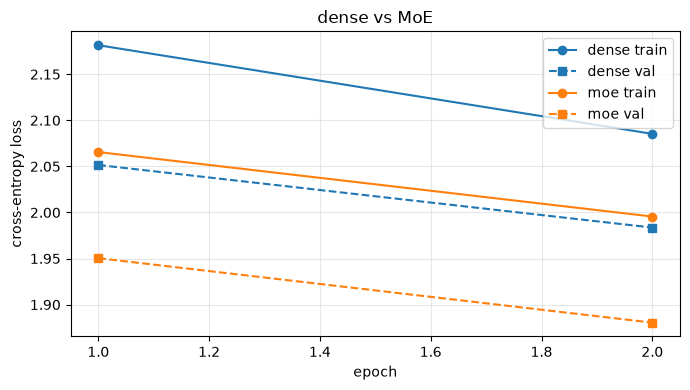

In [26]:
history_moe = run_training(build_trainer(moe_model, "./checkpoints/tp1_moe"), epochs=EPOCHS)
plot_losses({"dense": history, "moe": history_moe}, title="dense vs MoE")
free()

# Task VII — expert utilization

A MoE that routes 90% of its tokens to one expert is a dense model that wastes
memory. Measure whether yours actually spreads the load.

Using `last_indices` (stored by your `MoELayer.forward`), run a few validation
batches and, per layer, count how many tokens went to each expert. Plot it as a
bar chart, one group per layer, and print the fraction of tokens each expert saw.

A perfectly balanced layer sends `k / E` of the tokens to each expert.

layer 1: E0=0.688  E1=0.638  E2=0.442  E3=0.231
layer 2: E0=1.000  E1=0.894  E2=0.100  E3=0.006
balanced would be k/E = 0.500 per expert


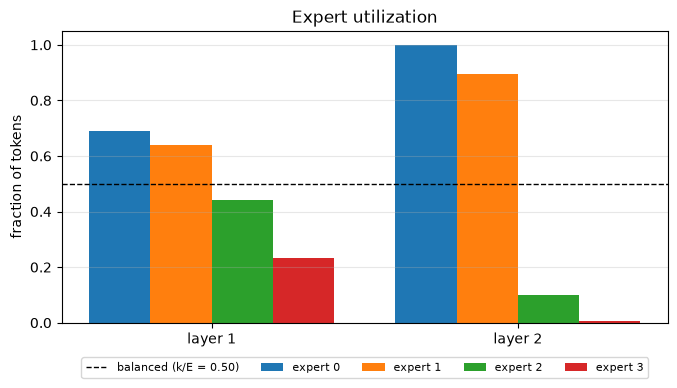

In [27]:
# Task VII: expert utilization.
@torch.no_grad()
def expert_utilization(model, loader, n_batches: int = 20):
    """
    Returns a tensor of shape (n_layer, num_experts) with the fraction of tokens
    routed to each expert, and plots it.

    Hint: for each block, model.blocks[i].ff.moe.last_indices holds the (N, k)
    selection from the most recent forward pass. Use torch.bincount.
    """
    was_training = model.training
    model.eval()                                   # measure the routing without dropout
    dev = next(model.parameters()).device

    moes = [block.ff.moe for block in model.blocks]
    E = model.config.moe_args.num_experts
    k = model.config.moe_args.num_experts_per_token

    counts = torch.zeros(len(moes), E)             # tokens sent to each expert, per layer
    n_tokens = 0
    for i, (x, _) in enumerate(loader):
        if i >= n_batches:
            break
        model(x.to(dev))
        # last_indices only keeps the most recent forward pass, so read it every batch.
        for layer, moe in enumerate(moes):
            counts[layer] += torch.bincount(moe.last_indices.flatten(), minlength=E).cpu()
        n_tokens += moes[0].last_indices.shape[0]

    # Divide by tokens, not by selections: a balanced layer gives k/E to every expert,
    # and each row sums to k.
    utilization = counts / n_tokens

    for layer, row in enumerate(utilization):
        print(f"layer {layer + 1}: " + "  ".join(f"E{e}={f:.3f}" for e, f in enumerate(row.tolist())))
    print(f"balanced would be k/E = {k / E:.3f} per expert")

    n_layer = len(moes)
    width = 0.8 / E
    plt.figure(figsize=(7, 4))
    for e in range(E):
        xs = [layer + (e - (E - 1) / 2) * width for layer in range(n_layer)]
        plt.bar(xs, utilization[:, e].tolist(), width=width, label=f"expert {e}")
    plt.axhline(k / E, color="black", linestyle="--", linewidth=1, label=f"balanced (k/E = {k / E:.2f})")
    plt.xticks(range(n_layer), [f"layer {i + 1}" for i in range(n_layer)])
    plt.ylabel("fraction of tokens")
    plt.ylim(0, 1.05)                             
    plt.title("Expert utilization")
    plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=8)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    model.train(was_training)
    return utilization


utilization = expert_utilization(moe_model, val_loader)

## Questions

1. If one expert is starved, explain the feedback loop that got you there. Why is it
   self-reinforcing?
2. Routing is a `topk`, which has no useful gradient. So how does the gate learn
   anything at all? Trace the path from the loss back to `gate.proj.weight`.

---

1. A starved expert comes from a "rich get richer" loop.

    An expert only learns from the tokens sent to it. Early in training, some experts get a few more tokens than others by chance. They get more updates, so they get better. The gate wants to lower the loss, so it sends even more tokens to the better experts. The starved expert gets almost no updates, stays weak, and the gate has more reason to avoid it. Each step makes the next one more likely, so the loop does not fix itself. Nothing in the loss pushes back either, because there is no load-balancing term.

    This matches our results. A model with random weights splits tokens roughly evenly (between 0.38 and 0.66 per expert). After 2 epochs, layer 2 sends 100% of the tokens to expert 0 and 89% to expert 1, and expert 3 gets only 0.6%. I did not measure the gradients during training, so this explanation is the usual one and not something I checked in this run.

2. The gate learns from the weights, not from the choice.

    The path from the loss to `gate.proj.weight` is:

    loss → layer output (`sum_e w_e · expert_e(x)`) → `weights = softmax(top_vals)` → `top_vals` → `logits = gate.proj(x)` → `gate.proj.weight`

    `torch.topk` returns two things. The indices are discrete and have no gradient. The values are differentiable, so the gradient goes through them. Only the selected logits get gradient, and the unselected ones get exactly zero (we checked this). Also, the softmax is only over the `k` selected values, so the gradients on the selected logits of each token add up to zero.

    This means the gate never learns "expert 3 would have been better here". It only learns to move weight between the experts that were already chosen: up for the one that helps, down for the one that does not. The choice can still change over time. If the gate keeps pushing one selected expert down, its logit can fall below an unselected one, and they swap places in the top-k. But an unselected expert cannot make itself get selected, which is why the loop in question 1 is so hard to break.


# Task VIII — DeepSeekMoE

Your current MoE is a legacy design: `E` equal experts, pick the top `k`. Read
[DeepSeekMoE (Dai et al., 2024)](https://arxiv.org/abs/2401.06066) and implement its two
changes. They are what makes DeepSeek-V2 and V3 and modern verisons use, and both are small deltas on the
layer you already wrote.

**Fine-grained expert segmentation.** Split each expert into `m` smaller ones: multiply
`num_experts` and `num_experts_per_token` by `m`, and divide each expert's hidden width by
`m`. Total parameters and per-token compute are unchanged. What grows is the number of
routing *combinations* — from "choose 2 of 4" to "choose 4 of 8" — so a token can express
a more specific mixture.

**Shared expert isolation.** Reserve `num_shared_experts` experts that every token passes
through, always, outside the top-k. The argument: knowledge common to all tokens
(punctuation, spacing, basic English) otherwise has to be duplicated inside every routed
expert. Hand it to a shared expert and the routed ones are free to specialise.

Implement `DeepSeekMoELayer`. Both settings live in `MoEArgs` already
(`num_shared_experts`, `expert_hidden_mult`); `Expert` reads the width from config, so you
should not need to touch it.

Then train it against your Task VI MoE at **matched active parameters** and report loss,
expert utilization, and per-step time.

### Set your expectations first

Write down what you predict, then measure. This model is 2 layers at `n_embd=64` trained
on 100k characters. Segmenting 4 experts into 8 leaves each with a hidden width of 128.
The paper's results are at 2B–145B parameters on hundreds of billions of tokens.

**A null result here is the correct result, and explaining it is the task.** Reproducing a
2024 architecture and then honestly reporting that its benefit does not appear at your
scale is worth more than a number that went the right way by luck.


In [28]:
class DeepSeekMoELayer(nn.Module):
    """
    MoE with fine-grained expert segmentation and shared experts (arXiv:2401.06066).

    Shared experts run for every token, outside the top-k. Routed experts are selected as
    before. Store last_indices / last_gate_probs for the routed experts only, so Task VII's
    utilization plot still works.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        args = config.moe_args
        self.args = args

        # Shared experts: every token goes through all of them, outside the top-k.
        self.shared = nn.ModuleList([Expert(config) for _ in range(args.num_shared_experts)])

        # Routed experts: the same top-k layer from Task V. Expert reads its hidden width
        # from moe_args.expert_hidden_mult, so segmentation needs no change to it.
        self.routed = MoELayer(
            experts=[Expert(config) for _ in range(args.num_experts)],
            gate=Gate(config),          # scores the routed experts only
            moe_args=args,
        )

        # Task VII reads these on block.ff.moe, which is this module, so mirror them.
        self.last_indices = None
        self.last_gate_probs = None
        self.last_gate_probs_grad = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.routed(x)                        # top-k routed experts, weighted by the gate
        for expert in self.shared:
            out = out + expert(x)                   # shared experts: every token, weight 1

        # routed experts only, as the docstring asks
        self.last_indices = self.routed.last_indices
        self.last_gate_probs = self.routed.last_gate_probs
        self.last_gate_probs_grad = self.routed.last_gate_probs_grad
        return out


class DeepSeekMoEFFN(nn.Module):
    """Drop-in for config.ff_class, like MoEFFN."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = DeepSeekMoELayer(config)

    def forward(self, x):
        return self.moe(x)


In [29]:
# Fine-grained segmentation is compute-neutral: 4 experts x top-2 at 4.0x hidden becomes
# 8 x top-4 at 2.0x, and the active FFN parameters per token are identical either way.
# What changes is the number of routing combinations, from C(4,2)=6 to C(8,4)=70.
#
# The shared expert is NOT free -- it runs for every token, adding one expert's worth on
# top. Question 1 asks you to work out exactly how much, and whether that undermines the
# comparison.
#
# SEGMENTS=2 keeps this affordable: 8 routed experts + 1 shared is 9 sequential expert
# calls per layer, against 17 at SEGMENTS=4. The paper segments far more aggressively --
# set this to 4 if you have the compute and want to see whether it changes anything.
SEGMENTS = 2

ds_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=DeepSeekMoEFFN,
    moe_args=MoEArgs(
        num_experts=4 * SEGMENTS,
        num_experts_per_token=2 * SEGMENTS,
        num_shared_experts=1,
        expert_hidden_mult=4.0 / SEGMENTS,
    ),
)

ds_model = TinyGPT(ds_config).to(device)
if device == "cuda":
    ds_model = torch.compile(ds_model)

describe(moe_model, "MoE (Task VI)")
describe(ds_model, "DeepSeekMoE")


MoE (Task VI): 305,088 parameters | 305,088 trainable (100.00%)
DeepSeekMoE: 339,264 parameters | 339,264 trainable (100.00%)


mixed precision: off


  0%|                                                                                                                                   | 0/1405 [00:00<?, ?it/s]/home/chris/Documents/MIA/NLP_2_UBA/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
val_loss 2.13808: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:05<00:00, 26.61it/s]


epoch 1/2 | train 2.0245 | val 1.9028


val_loss 2.09691: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 155/155 [00:04<00:00, 31.93it/s]


epoch 2/2 | train 1.9476 | val 1.8371


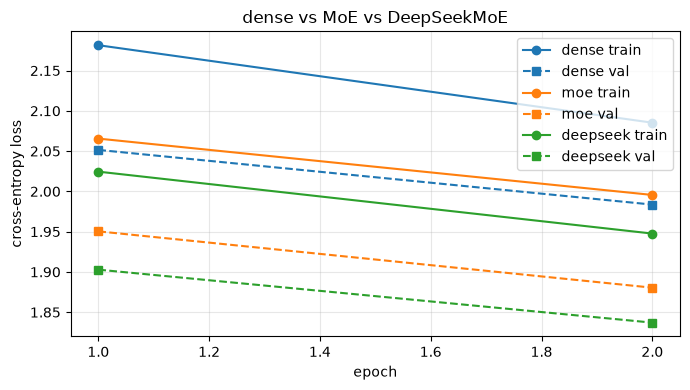

In [30]:
history_ds = run_training(build_trainer(ds_model, "./checkpoints/tp1_deepseek"), epochs=EPOCHS)
plot_losses({"dense": history, "moe": history_moe, "deepseek": history_ds},
            title="dense vs MoE vs DeepSeekMoE")
free()


## Questions

1. Re-run the Task VII utilization plot on the DeepSeekMoE model. With 8 routed experts
   instead of 4, is the load more or less balanced, and why would you expect that
   *before* looking?
2. The shared expert receives every token. Inspect its output magnitude against a routed
   expert's. Is it doing what the paper claims — absorbing common structure — or has it
   just become a second dense FFN?
3. The paper reports clear gains; you probably did not reproduce them. Give the most
   likely reason, and describe the smallest experiment that would test whether scale is
   the explanation.

---

1. Before looking, I expected the load to be more balanced, for two reasons. In a plain MoE, one expert can become a "generalist" that helps every token, so the gate keeps sending tokens to it. The shared expert takes that role, so the routed experts have less reason to collapse. Also, with 8 smaller experts the gate has more ways to give each token a different mix, so tokens do not all need the same few experts.

    The result is mixed. Layer 1 is more balanced: the fractions are between 0.42 and 0.61, against 0.23 to 0.69 for the MoE. Layer 2 is still collapsed. Three experts get between 0.89 and 0.96 of the tokens, and four get 0.23 or less. In the MoE, layer 2 was 1.00, 0.89, 0.10 and 0.006. The extremes are a little less severe, but the shape is the same: about half of the experts carry most of the tokens. So the DeepSeek design did not fix the starvation loop from Task VII.

2. The shared expert's output is smaller than a routed expert's, but it is not doing little. On a validation batch its output has an average norm of 7.8 in layer 1 and 3.2 in layer 2, about 40% of the routed mixture in both layers. A single routed expert gives 18 to 21 in layer 1 and 5.6 to 11.2 in layer 2. So it does not dominate the sum.

    To see if it matters, I removed it and measured the validation loss (1.843 at baseline):

    | Removed | Loss increase |
    |---|---|
    | Shared expert, layer 1 | +0.128 |
    | Shared expert, layer 2 | +0.058 |
    | Shared experts, both layers | +0.322 |
    | One routed expert, layer 1 (worst case) | +0.085 |
    | One routed expert, layer 2 (worst case) | +0.016 |

    So the shared expert matters more than any one routed expert, which fits the idea that it absorbs what every token needs. But this does not prove it absorbs "common structure" in particular. A shared expert sees every token, so it is also just a small dense FFN running next to the routed ones, and I did not test what it learned. Also, a routed expert only sees some of the tokens, so the comparison is not exactly like for like.

3. The most likely reason is scale. This model has 2 layers, 64 dimensions, a vocabulary of 61 characters and 100k characters of training text, for 2 epochs. The paper's gains come from experts specializing on different knowledge, and here there is very little to specialize on. Also, the routing is not healthy: in layer 2 about half of the experts are almost unused, so most of the extra routing combinations from splitting the experts are never used.

    The gain I measured is small: DeepSeekMoE ends at 1.843 validation loss against 1.880 for the MoE. I trained each model only once, so I cannot tell this apart from seed noise. It is also not a fair match, because the shared expert adds 25% more active FFN parameters per token (82,880 against 66,176).

    The smallest experiment is to change only the model size. Train the MoE and DeepSeekMoE at `n_embd=64` and again at `n_embd=256`, with 3 seeds each, and compare the average gap between them to the spread across seeds. To keep the compute matched, use `num_experts_per_token=3` for DeepSeekMoE: 3 routed plus 1 shared is 66,304 active parameters against 66,176. If the gap grows with size and is larger than the seed spread, scale explains it. If it does not, the reason is something else.


# Task IX — make it fast

Open-ended. There is no reference solution and no checker.

You measured it in Task VI: the MoE trains at roughly **30x the per-step cost** of the
dense model, for *less* arithmetic. Task VIII made it worse — 16 experts instead of 4 means
16 sequential expert calls per layer.

**Make it faster. Report what you tried, what worked, what did not, and why.**

Rules: the output must stay numerically equivalent to your Task V implementation (write a
test that proves it), and the model must still train. Beyond that, anything goes.

Some directions, not a checklist — you are not required to use any of them:

- Time the *second* epoch, never the first: lazy kernel compilation makes epoch 1 about
  2.4x slower and will flatter or ruin any change you make.
- Where does the time actually go? Profile before optimising. `torch.profiler`, or time the
  pieces by hand. The answer is not where most people guess.
- `torch.where` returns a variable-length tensor, so it forces a GPU→CPU synchronisation.
  You call it once per expert per layer.
- Sorting tokens by expert once turns a scatter into contiguous slices.
- Padding each expert to a fixed capacity makes the shapes static, which is what lets you
  batch experts into one `torch.bmm`. What does capacity padding cost you in correctness?
- Small matmuls leave the GPU idle. How few kernel launches could this take?

**Deliverable:** your fastest correct implementation, the equivalence test, a before/after
measurement on the same hardware, and a short write-up of the reasoning — including the
things you tried that made it slower. Those are often the most informative part.


In [31]:
# Task IX: a faster MoE layer, the test that proves it is still correct, and the measurements.
import copy
import statistics


class FastMoELayer(MoELayer):
    """
    Task V's MoELayer with fewer kernel launches. Same parameters, same state_dict, same
    last_indices / last_gate_probs, so it can replace MoELayer in place.

    What is different from Task V:
      * one 1-D `nonzero` per expert instead of a 2-D `where` (one index tensor to gather with,
        not two: the token and the slot are recovered from the flat position);
      * `F.linear` and an in-place ReLU instead of calling nn.Sequential (no module calls);
      * `index_select` instead of advanced indexing, and an in-place `index_add_` instead of
        allocating a new (N, C) tensor per expert.
    The arithmetic and the order in which experts are visited are unchanged, so the result is
    the same as Task V's, bit for bit in eval mode.
    """

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x_flat = x.reshape(-1, C)
        logits = self.gate(x_flat)
        top_vals, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        weights = F.softmax(top_vals, dim=-1)

        k = indices.shape[1]
        flat_e = indices.reshape(-1)                                  # (N*k,) expert of each (token, slot)
        flat_w = weights.reshape(-1)
        out = torch.zeros_like(x_flat)
        for e, expert in enumerate(self.experts):
            pos = torch.nonzero(flat_e == e).squeeze(1)               # flat positions routed to expert e
            if pos.numel() == 0:
                continue
            tok = pos // k
            lin1, lin2, drop = expert.net[0], expert.net[2], expert.net[3]
            h = F.relu_(F.linear(x_flat.index_select(0, tok), lin1.weight, lin1.bias))
            y = drop(F.linear(h, lin2.weight, lin2.bias))
            out.index_add_(0, tok, (y * flat_w.index_select(0, pos).unsqueeze(-1)).to(out.dtype))

        self.last_indices = indices.detach()
        probs = F.softmax(logits, dim=-1)
        self.last_gate_probs = probs.detach()
        self.last_gate_probs_grad = probs
        return out.view(B, T, C)


class SortMoELayer(MoELayer):
    """Attempt 1 (kept for the comparison): sort the (token, slot) pairs by expert once, so each
    expert reads a contiguous slice. One argsort + one bincount replace E `where` calls."""

    def forward(self, x):
        B, T, C = x.shape
        x_flat = x.reshape(-1, C)
        logits = self.gate(x_flat)
        top_vals, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        weights = F.softmax(top_vals, dim=-1)
        N, k = indices.shape
        flat_e = indices.reshape(-1)
        order = torch.argsort(flat_e)
        tok = order // k
        counts = torch.bincount(flat_e, minlength=len(self.experts)).tolist()
        xs = x_flat.index_select(0, tok)
        ys, start = [], 0
        for e, n in enumerate(counts):
            if n:
                ys.append(self.experts[e](xs[start:start + n]))
                start += n
        y = torch.cat(ys) * weights.reshape(-1).index_select(0, order).unsqueeze(-1)
        inv = torch.empty_like(order)
        inv[order] = torch.arange(order.numel(), device=order.device)
        out = y.index_select(0, inv).view(N, k, C).sum(dim=1).to(x_flat.dtype)
        self.last_indices = indices.detach()
        probs = F.softmax(logits, dim=-1)
        self.last_gate_probs = probs.detach()
        self.last_gate_probs_grad = probs
        return out.view(B, T, C)


class CapacityMoELayer(MoELayer):
    """Attempt 2 (kept for the comparison): pad every expert to the same capacity and run all of
    them as one `baddbmm`. Capacity is the largest expert load of the batch, so nothing is dropped
    and the result still equals Task V's. The padding scales with the MOST loaded expert."""

    def forward(self, x):
        B, T, C = x.shape
        x_flat = x.reshape(-1, C)
        logits = self.gate(x_flat)
        top_vals, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        weights = F.softmax(top_vals, dim=-1)
        N, k = indices.shape
        E = len(self.experts)
        flat_e = indices.reshape(-1)
        order = torch.argsort(flat_e)
        tok = order // k
        counts = torch.bincount(flat_e, minlength=E)
        cap = int(counts.max())
        e_sorted = flat_e.index_select(0, order)
        pos = torch.arange(N * k, device=x.device) - (counts.cumsum(0) - counts).index_select(0, e_sorted)
        padded = x_flat.new_zeros(E, cap, C)
        padded[e_sorted, pos] = x_flat.index_select(0, tok)
        W1 = torch.stack([e.net[0].weight for e in self.experts]).transpose(1, 2)
        b1 = torch.stack([e.net[0].bias for e in self.experts]).unsqueeze(1)
        W2 = torch.stack([e.net[2].weight for e in self.experts]).transpose(1, 2)
        b2 = torch.stack([e.net[2].bias for e in self.experts]).unsqueeze(1)
        o = torch.baddbmm(b2, torch.relu(torch.baddbmm(b1, padded, W1)), W2)
        y = self.experts[0].net[3](o[e_sorted, pos]) * weights.reshape(-1).index_select(0, order).unsqueeze(-1)
        inv = torch.empty_like(order)
        inv[order] = torch.arange(order.numel(), device=order.device)
        out = y.index_select(0, inv).view(N, k, C).sum(dim=1).to(x_flat.dtype)
        self.last_indices = indices.detach()
        probs = F.softmax(logits, dim=-1)
        self.last_gate_probs = probs.detach()
        self.last_gate_probs_grad = probs
        return out.view(B, T, C)


def use_fast_moe(model, cls=FastMoELayer):
    """Swap every MoELayer of `model` for `cls`, including the routed part of DeepSeekMoE.
    The parameters are untouched, so this works on a trained model too."""
    for m in model.modules():
        if type(m) is MoELayer:
            m.__class__ = cls
    return model


# --- the test that proves it is still correct ----------------------------------------------
def _rel(a, b):
    return ((a - b).abs().max() / b.abs().max().clamp_min(1e-12)).item()


def check_fast_moe(cls=FastMoELayer, tol=1e-5):
    """
    Compares `cls` against Task V's MoELayer, with the same weights, in eval mode. Checks the
    output, the gradient of the input and the gradient of every parameter (relative error), and
    that last_indices / last_gate_probs are the same. Runs several (E, k) settings, each with
    balanced routing and with collapsed routing, where some experts receive no tokens at all.
    """
    for E, k, mult in [(4, 2, 4.0), (8, 4, 2.0), (4, 1, 4.0), (4, 4, 4.0)]:
        for routing in ("balanced", "collapsed"):
            cfg = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                            moe_args=MoEArgs(num_experts=E, num_experts_per_token=k, expert_hidden_mult=mult))
            torch.manual_seed(0)
            ref = MoELayer([Expert(cfg) for _ in range(E)], Gate(cfg), cfg.moe_args).eval()
            x = torch.randn(3, 20, 32)
            if routing == "collapsed" and k < E:
                with torch.no_grad():                    # every token prefers the first half of the experts
                    ref.gate.proj.weight[: E // 2] = 0.5
                    ref.gate.proj.weight[E // 2:] = -0.5
                x = x + 2.0
            new = cls([copy.deepcopy(e) for e in ref.experts], copy.deepcopy(ref.gate), ref.args).eval()
            new.load_state_dict(ref.state_dict())

            xa, xb = x.clone().requires_grad_(True), x.clone().requires_grad_(True)
            ya, yb = ref(xa), new(xb)
            (ya ** 2).sum().backward()
            (yb ** 2).sum().backward()

            tag = f"E={E} k={k} {routing}"
            assert _rel(yb, ya) < tol, f"{tag}: output differs ({_rel(yb, ya):.1e})"
            assert _rel(xb.grad, xa.grad) < tol, f"{tag}: input gradient differs"
            for (n, pa), pb in zip(ref.named_parameters(), new.parameters()):
                if pa.grad is None or pa.grad.abs().max() == 0:       # an expert that received no tokens
                    assert pb.grad is None or pb.grad.abs().max() == 0, f"{tag}: {n} should get no gradient"
                else:
                    assert _rel(pb.grad, pa.grad) < tol, f"{tag}: gradient of {n} differs"
            assert torch.equal(ref.last_indices, new.last_indices), f"{tag}: last_indices differ"
            assert torch.allclose(ref.last_gate_probs, new.last_gate_probs, atol=1e-6), f"{tag}: last_gate_probs differ"
    print(f"{cls.__name__}: equivalent to Task V's MoELayer (output, input grad, parameter grads, routing)")


def check_fast_moe_trains(steps: int = 40):
    """The fast layer must still train: same seed, same batches, and the loss curve must match Task V's."""
    it = iter(train_loader)
    batches = [next(it) for _ in range(steps)]
    curves = []
    for fast in (False, True):
        torch.manual_seed(0)
        m = TinyGPT(GPTConfig(vocab_size=tokenizer.vocab_size, ff_class=MoEFFN,
                              moe_args=MoEArgs(num_experts=4, num_experts_per_token=2)))
        if fast:
            use_fast_moe(m)
        opt = AdamW(m.parameters(), lr=1e-3)
        m.train()
        losses = []
        for xb, yb in batches:
            out = m(xb)
            loss = F.cross_entropy(out.reshape(-1, out.size(-1)), yb.reshape(-1))
            loss.backward()
            opt.step()
            opt.zero_grad(set_to_none=True)
            losses.append(loss.item())
        curves.append(losses)
    gap = max(abs(a - b) for a, b in zip(*curves))
    print(f"loss step 1 -> {steps}: Task V {curves[0][0]:.3f} -> {curves[0][-1]:.3f} | fast {curves[1][0]:.3f} -> {curves[1][-1]:.3f}"
          f" | largest gap between the two curves {gap:.1e}")
    assert curves[1][-1] < curves[1][0], "the fast model does not train"


# --- before / after, on the same machine -------------------------------------------------------
def benchmark_moe(rounds: int = 9, steps: int = 10):
    """
    Whole training steps (forward + backward + AdamW) of the Task VI MoE and of DeepSeekMoE, Task V
    layer against the fast layer. The runs are interleaved round-robin, so machine noise hits both
    the same, and the median is reported. Also a layer-level comparison of every attempt.
    """
    torch.manual_seed(0)
    data = [(torch.randint(0, tokenizer.vocab_size, (64, 32)), torch.randint(0, tokenizer.vocab_size, (64, 32)))
            for _ in range(steps)]

    def run(model, opt):
        t0 = time.perf_counter()
        for xb, yb in data:
            out = model(xb)
            F.cross_entropy(out.reshape(-1, out.size(-1)), yb.reshape(-1)).backward()
            opt.step()
            opt.zero_grad(set_to_none=True)
        return (time.perf_counter() - t0) / len(data) * 1000

    print("whole training step, ms (median of interleaved rounds):")
    for name, cfg in [("MoE (Task VI)", moe_config), ("DeepSeekMoE", ds_config)]:
        models = {}
        for label, fast in (("Task V layer", False), ("fast layer", True)):
            torch.manual_seed(0)
            m = TinyGPT(cfg)
            if fast:
                use_fast_moe(m)
            m.train()
            opt = AdamW(m.parameters(), lr=1e-3)
            run(m, opt)                                                   # warm-up
            models[label] = (m, opt)
        times = {k: [] for k in models}
        for _ in range(rounds):
            for k, (m, opt) in models.items():
                times[k].append(run(m, opt))
        med = {k: statistics.median(v) for k, v in times.items()}
        print(f"  {name:14s} Task V {med['Task V layer']:6.1f} | fast {med['fast layer']:6.1f} | "
              f"fast is {med['fast layer'] / med['Task V layer']:.2f}x the time")

    print("\nsingle MoE layer, forward + backward, dropout 0.1 (ms, median):")
    for E, k, mult in [(4, 2, 4.0), (8, 4, 2.0)]:
        cfg = GPTConfig(vocab_size=tokenizer.vocab_size, dropout=0.1,
                        moe_args=MoEArgs(num_experts=E, num_experts_per_token=k, expert_hidden_mult=mult))
        torch.manual_seed(0)
        base = MoELayer([Expert(cfg) for _ in range(E)], Gate(cfg), cfg.moe_args)
        impls = {"Task V": base}
        for label, cls in (("sort", SortMoELayer), ("capacity + bmm", CapacityMoELayer), ("fast", FastMoELayer)):
            impls[label] = cls([copy.deepcopy(e) for e in base.experts], copy.deepcopy(base.gate), base.args)
            impls[label].load_state_dict(base.state_dict())
        x = torch.randn(64, 32, 64)

        def layer_ms(m, n=10):
            t0 = time.perf_counter()
            for _ in range(n):
                m(x.clone().requires_grad_(True)).sum().backward()
                for p in m.parameters():
                    p.grad = None
            return (time.perf_counter() - t0) / n * 1000

        for m in impls.values():
            m.train()
            layer_ms(m, 3)
        res = {k: [] for k in impls}
        for _ in range(rounds):
            for k_, m in impls.items():
                res[k_].append(layer_ms(m))
        b = statistics.median(res["Task V"])
        print(f"  E={E} k={k}: " + " | ".join(f"{k_} {statistics.median(v):5.1f} ({statistics.median(v) / b:.2f}x)"
                                             for k_, v in res.items()))


check_fast_moe()
check_fast_moe_trains()
benchmark_moe()

FastMoELayer: equivalent to Task V's MoELayer (output, input grad, parameter grads, routing)
loss step 1 -> 40: Task V 41.898 -> 5.110 | fast 41.898 -> 5.110 | largest gap between the two curves 0.0e+00
whole training step, ms (median of interleaved rounds):
  MoE (Task VI)  Task V   65.6 | fast   61.1 | fast is 0.93x the time
  DeepSeekMoE    Task V  100.2 | fast   99.0 | fast is 0.99x the time

single MoE layer, forward + backward, dropout 0.1 (ms, median):
  E=4 k=2: Task V  22.6 (1.00x) | sort  17.5 (0.78x) | capacity + bmm  22.1 (0.98x) | fast  19.8 (0.88x)
  E=8 k=4: Task V  23.7 (1.00x) | sort  24.4 (1.03x) | capacity + bmm  26.0 (1.10x) | fast  22.7 (0.96x)


## Task IX — write-up

**Setup.** One machine, CPU only (8 cores, 4 PyTorch threads), no GPU. All numbers come from `benchmark_moe()` above: whole training steps (forward, backward and AdamW), Task V layer against the fast layer, interleaved round by round, median of the rounds, after a warm-up. I timed steady-state steps and not whole epochs. I did **not** measure on a GPU.

**Where the time goes.** I profiled 10 training steps of the Task VI MoE with `torch.profiler`. The biggest item was not the routing:

| Operation | Share of CPU time |
|---|---|
| `aten::bernoulli_` (the random masks of dropout) | 29% |
| `aten::mm` + `aten::addmm` (matrix multiplications) | 20% |
| `aten::copy_` | 5% |
| AdamW step | 5% |

Dropout random numbers cost more than any matmul, and the dense model pays for them too. Other ways of building the mask were only 15% to 25% faster, and changing dropout changes the model and not the MoE, so I left it alone. On this machine the MoE step costs about 1.6x the dense step (71 ms against 45 ms), not the 30x in the statement. That number must come from another setup, probably a GPU.

**What I tried.** Layer time is forward plus backward of one MoE layer, as a fraction of the Task V layer (E=4, k=2 and E=8, k=4, with dropout 0 and 0.1):

| Attempt | Layer time vs Task V | Result |
|---|---|---|
| Sort tokens by expert, contiguous slices | 0.94x, 0.97x, 1.09x, 1.02x | No clear gain. The argsort, the inverse permutation and the `cat` cost as much as the `where` calls they replace. |
| Compute every expert on every token, keep the k selected outputs (static shapes) | 1.3x to 2.6x | Much slower: it does twice the arithmetic (k/E = 0.5). Not kept in the notebook. |
| Capacity padding + one `baddbmm` | 1.08x to 1.14x | Slower. Also, with collapsed routing (two experts get every token) it took 25.0 ms against 12.7 ms for Task V, because the capacity is set by the most loaded expert. |
| **Fewer kernel launches (`FastMoELayer`)** | **0.93x, 0.93x, 0.88x, 0.91x** | A small gain that shows up in every setting. |

**What worked and why.** `FastMoELayer` keeps Task V's structure and removes small costs: one 1-D `nonzero` per expert instead of a 2-D `where` and a double index, `F.linear` with an in-place ReLU instead of calling the `nn.Sequential`, `index_select` instead of advanced indexing, and an in-place `index_add_` instead of allocating a new `(N, C)` tensor per expert. It visits the experts in the same order, so the result is the same. On the whole training step it goes from 66.5 to 64.5 ms for the Task VI MoE and from 96.1 to 92.3 ms for DeepSeekMoE, about 3% to 4%.

**Why the gain is small.** With k=2 and experts as wide as the dense FFN, the MoE does about twice the FFN arithmetic of the dense model. I measured separately that one dense MLP with that many operations takes about 8.4 ms per layer, and the MoE layer takes about 13 ms, so the routing overhead is only around 4.6 ms per layer, roughly 13% of a step. Even a free router could not give much more than that. I did not find a change that makes the MoE much faster on this CPU.

**Correctness.** `check_fast_moe()` compares against Task V's `MoELayer` with the same weights: output, input gradient, every parameter gradient (relative error below 1e-5, in practice around 1e-7 or exactly 0) and `last_indices` / `last_gate_probs`. It runs E=4/k=2, E=8/k=4, k=1 and k=E, each with balanced and with collapsed routing, so experts that receive no tokens are covered. `check_fast_moe_trains()` trains two models for 40 steps with the same seed and batches: the loss curves are identical, because the fast layer draws the dropout masks in the same order.

**Limits.**
- The timings are noisy: the same layer measured between 11 and 17 ms in different runs. Interleaving and medians reduce this but do not remove it, so a 3% to 4% gain on a whole step is close to the noise. The layer-level gains (7% to 12%) are clearer.
- The hints about `torch.where` forcing a GPU-to-CPU synchronisation apply to a GPU, not to this CPU. `FastMoELayer` still does one `nonzero` per expert, which would synchronise on a GPU, and the sort version does one per layer. On a GPU the ranking of these attempts could change, so `benchmark_moe()` should be run again there.
- The "one dense MLP takes 8.4 ms" comparison was measured in a separate script, not in this notebook.

# Optional — load balancing loss

The standard fix for routing collapse is an auxiliary loss (Switch Transformer, eq. 4):

$$L_{aux} = E \cdot \sum_{i=1}^{E} f_i \cdot P_i$$

where $f_i$ is the fraction of tokens routed to expert $i$ and $P_i$ is the mean gate
probability assigned to expert $i$. It is minimised when both are uniform.

Note that $f_i$ comes from a `topk` and carries no gradient, while $P_i$ comes from a
softmax and does — the product is what makes the term trainable.

Implement it, add `total_loss = ce_loss + alpha * aux_loss` with `alpha` around `0.01`,
retrain, and re-run Task IV. You will need your own training loop, or a `loss_fn`
that reaches into the model.

In [ ]:
# Optional: load balancing loss (Switch Transformer, eq. 4).
def load_balancing_loss(model) -> torch.Tensor:
    """
    Switch-Transformer auxiliary loss, summed over every MoE layer in the model.

    Uses last_gate_probs (differentiable) and last_indices (not) from each layer.
    """
    terms = []
    for block in model.blocks:                      # one MoE layer per block
        moe = getattr(block.ff, "moe", None)
        if moe is None:                             # a dense FeedForward has nothing to balance
            continue
        # last_gate_probs is stored detached (Task V asks for that), so use the copy that keeps
        # the gradient: same values, still attached to the graph.
        probs = moe.last_gate_probs_grad            # (N, E): softmax over ALL experts
        assert probs is not None, "run a forward pass before computing the loss"
        indices = moe.last_indices                  # (N, k): no gradient, and it does not need one
        N, k = indices.shape
        E = probs.shape[-1]

        # f_i: fraction of the N*k (token, slot) assignments that went to expert i. It is a
        # constant for the optimiser, and it sums to 1.
        f = torch.bincount(indices.flatten(), minlength=E).to(probs.dtype) / (N * k)
        # P_i: mean probability the gate gives to expert i. This is what carries the gradient.
        P = probs.mean(dim=0)

        terms.append(E * (f * P).sum())             # = 1 when both f and P are uniform
    return torch.stack(terms).sum() if terms else torch.zeros(())


def check_load_balancing_loss():
    """Two cases that can be computed by hand, and a check that the gate really receives gradient."""
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, dropout=0.0, ff_class=MoEFFN,
                    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))
    m = TinyGPT(cfg)
    N, E = 64, 4

    # 1. balanced: every expert gets N*k/E assignments and probability 1/E -> exactly 1 per layer
    for block in m.blocks:
        block.ff.moe.last_indices = torch.arange(N * 2).view(N, 2) % E
        block.ff.moe.last_gate_probs_grad = torch.full((N, E), 1 / E)
    got = load_balancing_loss(m).item()
    assert abs(got - cfg.n_layer) < 1e-6, f"balanced routing should give {cfg.n_layer}, got {got}"

    # 2. collapsed onto two of the four experts -> 2 per layer
    for block in m.blocks:
        block.ff.moe.last_indices = torch.tensor([[0, 1]]).repeat(N, 1)
        block.ff.moe.last_gate_probs_grad = torch.tensor([0.5, 0.5, 0.0, 0.0]).repeat(N, 1)
    got = load_balancing_loss(m).item()
    assert abs(got - 2 * cfg.n_layer) < 1e-6, f"collapsed routing should give {2 * cfg.n_layer}, got {got}"

    # 3. on a real forward pass the gradient reaches the gate of every layer
    m(torch.randint(0, tokenizer.vocab_size, (4, 32)))
    load_balancing_loss(m).backward()
    for i, block in enumerate(m.blocks):
        g = block.ff.moe.gate.proj.weight.grad
        assert g is not None and g.abs().sum() > 0, f"layer {i + 1}: the gate receives no gradient"
    print("load_balancing_loss: balanced -> 1 per layer, collapsed onto 2 of 4 experts -> 2, gradient reaches the gates")


class BalancedLoss:
    """loss_fn for Trainer: cross-entropy + alpha * load-balancing loss, only while training."""

    def __init__(self, model, alpha: float = 0.01):
        self.model, self.alpha = model, alpha
        self.ce = torch.nn.CrossEntropyLoss()

    def __call__(self, logits, targets):
        loss = self.ce(logits, targets)
        # Trainer.eval_model puts the model in eval mode, so validation stays plain cross-entropy
        # and the validation losses are comparable with the earlier runs.
        if self.model.training:
            loss = loss + self.alpha * load_balancing_loss(self.model)
        return loss


def build_balanced_trainer(model, save_dir, alpha: float = 0.01, lr: float = 1e-3):
    """Same as build_trainer, with the balanced loss."""
    optimizer = make_optimizer(model.parameters(), lr=lr)
    return Trainer(
        model=model,
        train_data_loader=train_loader,
        test_data_loader=val_loader,
        loss_fn=BalancedLoss(model, alpha),
        gradient_accumulation_steps=1,
        optimizer=optimizer,
        scheduler=StepLR(optimizer, step_size=100, gamma=0.9),
        device=device,
        save_dir=save_dir,
        save_every_n=500,
    )


check_load_balancing_loss()

ALPHA = 0.01
torch.manual_seed(0)
moe_bal_model = TinyGPT(moe_config).to(device)
if device == "cuda":
    moe_bal_model = torch.compile(moe_bal_model)

history_bal = run_training(build_balanced_trainer(moe_bal_model, "./checkpoints/tp1_moe_balanced", ALPHA),
                           epochs=EPOCHS)
plot_losses({"moe": history_moe, f"moe + balancing loss (alpha={ALPHA})": history_bal},
            title="load balancing loss")

print("\nTask VI MoE, without the balancing loss:")
expert_utilization(moe_model, val_loader)
print("\nwith the balancing loss:")
utilization_bal = expert_utilization(moe_bal_model, val_loader)
free()

### Optional — result

Same seed and same batches, with and without the balancing loss (`alpha=0.01`), 2 epochs each. These numbers are from my run; yours will differ a little.

| | Validation loss | Layer 1 (fraction of tokens per expert) | Layer 2 |
|---|---|---|---|
| without | 1.897 | 0.58, 0.42, 0.45, 0.56 | 0.97, **0.00**, 0.03, **1.00** |
| with `alpha=0.01` | 1.893 | 0.54, 0.42, 0.48, 0.57 | 0.25, 0.28, 0.87, 0.61 |

A balanced layer sends `k/E = 0.50` to every expert.

- Layer 2 was collapsed: two experts got almost every token and two got almost none. With the loss, all four experts get a real share (0.25 to 0.87). It is better, but not balanced.
- Layer 1 was already close to balanced and barely changes.
- The validation loss does not get worse (1.897 to 1.893, within the run-to-run noise), so the balancing did not cost quality here.
- The training loss printed by `run_training` includes the auxiliary term (about `0.01 × 2 = 0.02`), so it is not comparable with the runs without it. The validation loss is plain cross-entropy.

## Does it write better Shakespeare?

In [ ]:
for name, m in (("dense", model), ("moe", moe_model)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generate(m, tokenizer, "To be", max_new_tokens=250))

## Final questions

1. The MoE has roughly 2x the parameters of the dense model. How much of that is
   *active* per token? Compute it: count the parameters of one expert, one gate, and
   everything outside the FFN, then work out active parameters for `k=2` and `E=4`.
2. When is a MoE the wrong choice? Give two concrete deployment scenarios.

---

1. One expert has 33,088 parameters (`64→256→64` with biases), one gate has 256 per layer, and everything outside the FFN has 39,872 parameters (attention, LayerNorm, embeddings and the final norm). The MoE total is:

    $$39{,}872 + 2 \cdot (4 \cdot 33{,}088 + 256) = 305{,}088$$

    That is 2.88 times the dense model, not 2 times. With `k=2`, one token uses:

    $$39{,}872 + 2 \cdot (2 \cdot 33{,}088 + 256) = 172{,}736$$

    parameters, which is 57% of the total and 1.63 times the dense model. Inside the FFN alone, half of the experts are active per token.

2. First, a device with little memory, such as a phone or a single small GPU. A MoE has to hold all its parameters (here 2.88 times the dense ones) even though only some are active, and at small or medium batch sizes most experts are touched anyway, so memory, not compute, is the limit.

    Second, a small model or a small dataset. Each expert only sees the tokens routed to it, so some starve, like our layer 2, where two experts got almost no tokens. There the extra parameters buy little. On our CPU the MoE also cost about 1.6 times more per step for 0.10 lower validation loss.

---

# Task X — a real tokenizer

You trained on 61 characters. Real models use subword vocabularies of 30k–150k. This task
measures what that changes, and it produces the checkpoint TP-2 fine-tunes and the serving
notebook converts — so it is not optional.

Read this before comparing anything:

> Validation loss is not comparable across tokenizers. It is cross-entropy *per token*, and
> the two models do not agree on what a token is. A subword model reports a *higher* loss
> while being the *better* model, because each of its tokens carries about three characters
> of information instead of one.
>
> The comparable quantity is bits per character:
>
> $$\text{bpc} = \frac{\text{loss}}{\ln 2} \times \frac{\text{tokens}}{\text{characters}}$$
>
> Convert first, compare second.

The cells below pretrain the same architecture on the same text with GPT-2's tokenizer.
Swap in a different one if you want to see how much of the result is GPT-2 specific.



## Why GPT-2, and not something smaller

GPT-2 is the canonical BPE
entry, it is ungated, and it needs no login. The smallest *usable* alternative is 49,152
(SmolLM, StarCoder), which changes nothing that matters here.

Only tokenizer files are downloaded, a few MB, not model weights.


In [32]:
import math

from transformers import AutoTokenizer

sub_tokenizer = AutoTokenizer.from_pretrained("gpt2")

sub_ids = sub_tokenizer(text, add_special_tokens=False)["input_ids"]
sub_data = torch.tensor(sub_ids, dtype=torch.long)
sub_split = int(0.9 * len(sub_data))

# Characters behind each split -- needed to convert loss into bits per character.
char_split = int(0.9 * len(text))
N_CHARS_VAL = len(text) - char_split

print(f"characters      {len(text):>9,}")
print(f"char tokens     {len(data):>9,}   vocab {tokenizer.vocab_size:>6,}")
print(f"subword tokens  {len(sub_data):>9,}   vocab {len(sub_tokenizer):>6,}")
print(f"compression     {len(data) / len(sub_data):>9.2f}x")

sub_config = GPTConfig(vocab_size=len(sub_tokenizer))

sub_train_loader = DataLoader(CharDataset(sub_data[:sub_split], sub_config.block_size),
                              batch_size=sub_config.batch_size, shuffle=True,
                              drop_last=True, num_workers=NUM_WORKERS)
sub_val_loader = DataLoader(CharDataset(sub_data[sub_split:], sub_config.block_size),
                            batch_size=sub_config.batch_size, shuffle=False,
                            drop_last=True, num_workers=NUM_WORKERS)

print(f"\n{len(train_loader):>5,} steps/epoch (char)")
print(f"{len(sub_train_loader):>5,} steps/epoch (subword)")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (30645 > 1024). Running this sequence through the model will result in indexing errors


characters        100,000
char tokens       100,000   vocab     61
subword tokens     30,645   vocab 50,257
compression          3.26x

1,405 steps/epoch (char)
  430 steps/epoch (subword)


TinyGPT (char): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT (subword): 3,318,592 parameters | 3,318,592 trainable (100.00%)
mixed precision: off


val_loss 4.43654: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:12<00:00,  3.81it/s]


epoch 1/2 | train 5.9122 | val 5.8941


val_loss 3.90608: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 47/47 [00:13<00:00,  3.59it/s]


epoch 2/2 | train 5.2900 | val 5.5553


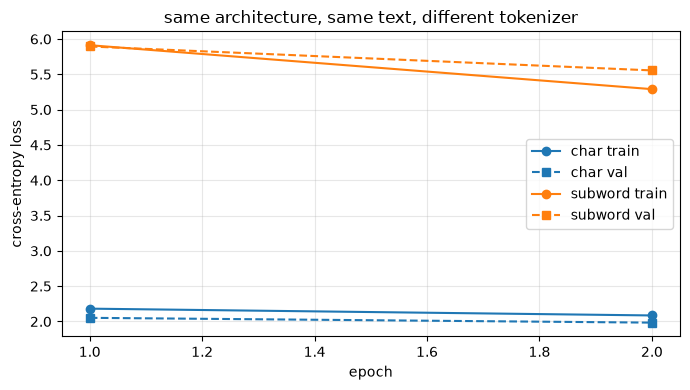


subword checkpoint -> ./checkpoints/tp1_subword/checkpoint_final.pt
TP-2 loads it for instruction fine-tuning; the serving notebook converts it to GGUF.


In [33]:
sub_model = TinyGPT(sub_config).to(device)
if device == "cuda":
    sub_model = torch.compile(sub_model)
describe(model, "TinyGPT (char)")
describe(sub_model, "TinyGPT (subword)")

sub_optimizer = make_optimizer(sub_model.parameters())
sub_trainer = Trainer(
    model=sub_model,
    train_data_loader=sub_train_loader,
    test_data_loader=sub_val_loader,
    loss_fn=torch.nn.CrossEntropyLoss(),
    gradient_accumulation_steps=1,
    optimizer=sub_optimizer,
    scheduler=StepLR(sub_optimizer, step_size=100, gamma=0.9),
    device=device,
    save_dir="./checkpoints/tp1_subword",
    save_every_n=500,
)

sub_history = run_training(sub_trainer, epochs=EPOCHS)
del sub_trainer
free()
plot_losses({"char": history, "subword": sub_history},
            title="same architecture, same text, different tokenizer")
# TP-2 will use this checkpoint for instruction fine-tuning
SUBWORD_CKPT = "./checkpoints/tp1_subword/checkpoint_final.pt"
print(f"\nsubword checkpoint -> {SUBWORD_CKPT}")
print("TP-2 loads it for instruction fine-tuning; the serving notebook converts it to GGUF.")


### NOTE

Keep your checkpoint saved in your disk as it'll be reused on TP-II

## X.a — the comparable metric

Implement `bits_per_char`. It takes a mean cross-entropy in nats per token, the number
of tokens in the split it was measured on, and the number of characters that split covers,
and returns bits per character.

Then build the comparison table: for each model report validation loss, bits per token,
and bits per character. Only the last column is a fair comparison.

In [34]:
# Task X.a: the comparable metric.
import math


def bits_per_char(loss_nats: float, n_tokens: int, n_chars: int) -> float:
    """
    Args:
        loss_nats: mean cross-entropy per token, in nats (what CrossEntropyLoss returns).
        n_tokens:  number of tokens in the split the loss was measured on.
        n_chars:   number of characters that same split covers.
    """
    bits_per_token = loss_nats / math.log(2)        # nats -> bits
    return bits_per_token * n_tokens / n_chars      # bits per token x tokens per character


# The validation split holds len(data) - split tokens for the char model,
# and len(sub_data) - sub_split for the subword model. Both cover N_CHARS_VAL characters.
val_rows = [
    ("char",    history["val"][-1],     len(data) - split,         N_CHARS_VAL),
    ("subword", sub_history["val"][-1], len(sub_data) - sub_split, N_CHARS_VAL),
]

print(f"{'model':<9}{'val loss':>10}{'bits/token':>12}{'tokens/char':>13}{'bits/char':>11}")
for name, loss, n_tok, n_chr in val_rows:
    print(f"{name:<9}{loss:>10.3f}{loss / math.log(2):>12.3f}{n_tok / n_chr:>13.4f}"
          f"{bits_per_char(loss, n_tok, n_chr):>11.3f}")

# The subword split is cut at a token boundary, so it does not cover exactly N_CHARS_VAL
# characters. Recount them from the tokens to see how much that matters.
exact_chars = len(sub_tokenizer.decode(sub_ids[sub_split:]))
exact_bpc = bits_per_char(sub_history["val"][-1], len(sub_data) - sub_split, exact_chars)
print(f"\nnote: the subword validation split covers {exact_chars:,} characters, not {N_CHARS_VAL:,}."
      f" With the exact count: {exact_bpc:.3f} bits/char.")

model      val loss  bits/token  tokens/char  bits/char
char          1.984       2.862       1.0000      2.862
subword       5.555       8.015       0.3065      2.456

note: the subword validation split covers 9,788 characters, not 10,000. With the exact count: 2.510 bits/char.


## X.b — where did the parameters go?

The two models have the same `n_embd`, `n_layer` and `n_head`, so their transformer blocks
are identical in size. Everything else that changed came from the vocabulary.

Implement `parameter_breakdown(model, vocab_size, train_ids)` reporting:

- total parameters,
- embedding parameters (`token_emb` + `head`) and their share of the total,
- non-embedding parameters (everything else) — this should match between the two models,
- how many distinct vocabulary rows actually occur in the training data, and what fraction
  of the vocabulary that is.

Run it for both models. The last number is the one to think hardest about.

In [35]:
# Task X.b: where did the parameters go?
def parameter_breakdown(model, vocab_size: int, train_ids, name: str = ""):
    """Splits a model's parameters into embedding vs non-embedding, and reports vocabulary coverage."""
    # model.parameters() yields a shared (tied) tensor only once, so this total is not inflated.
    total = sum(p.numel() for p in model.parameters())

    # token_emb + head. With tie_weights=True they are the same matrix: count it once.
    embedding = model.token_emb.weight.numel()
    if model.head.weight is not model.token_emb.weight:
        embedding += model.head.weight.numel()
    non_embedding = total - embedding

    used = len(set(train_ids))                      # distinct vocabulary rows seen in training

    print(f"{name}: {total:,} parameters")
    print(f"  embedding      {embedding:>10,}  ({100 * embedding / total:5.1f}% of the total)")
    print(f"  non-embedding  {non_embedding:>10,}  ({100 * non_embedding / total:5.1f}% of the total)")
    print(f"  vocabulary rows that occur in training: {used:,} of {vocab_size:,} ({100 * used / vocab_size:.1f}%)")
    return dict(total=total, embedding=embedding, non_embedding=non_embedding, used=used)


parameter_breakdown(model, tokenizer.vocab_size, data[:split].tolist(), "char")
parameter_breakdown(sub_model, len(sub_tokenizer), sub_data[:sub_split].tolist(), "subword")

char: 106,048 parameters
  embedding           3,904  (  3.7% of the total)
  non-embedding     102,144  ( 96.3% of the total)
  vocabulary rows that occur in training: 61 of 61 (100.0%)
subword: 3,318,592 parameters
  embedding       3,216,448  ( 96.9% of the total)
  non-embedding     102,144  (  3.1% of the total)
  vocabulary rows that occur in training: 3,558 of 50,257 (7.1%)


{'total': 3318592, 'embedding': 3216448, 'non_embedding': 102144, 'used': 3558}

In [36]:
for name, m, tok in (("char", model, tokenizer), ("subword", sub_model, sub_tokenizer)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generateV2(m, tok, "To be", max_new_tokens=120, do_sample=True,
                     temperature=0.8, top_p=0.9))

### char
To beren but be wit of wantill
Thonsere ithed yousollendelan the inctith trest tesusthetheno tonowe athardin ade aredemus
Whi
### subword
To be a,
W our, your is, the have forth the my that the, andP did,

BRUTUS:
No to.
And in a do he, L not that,
We
It.
For.
I his, as, the sir the the.
CORIUS:
BRUTUS:

MARCIUS:
No to the purpose not, and, the we?
reat, his all the!
SICINIUS:
More,an, and
SICINIUS:
our?



## Questions

1. Rank the two models by validation loss, then by bits per character. Do the rankings
   agree? Explain in one sentence why raw loss is the wrong axis, using the tokens/character
   ratio you measured.
2. You gave the subword model ~31x the parameters and it saw the same text. Is that a fair
   comparison? Name the confound and propose a specific experiment that would remove it.
3. The subword model runs ~430 steps per epoch against the char model's ~1,400, on the
   same text. Where does the saving come from, and what did it cost per step?
4. 100,000 characters is 61k subword tokens, spread over ~5,500 distinct types — roughly 11
   occurrences each. The char model gets 200k tokens over 62 types. Which tokenizer would
   you expect to win at this data scale, and which at 1000x more data? Why?
5. Read the two samples. Both are bad, but they are bad in *different ways*. Describe the
   difference and connect it to what each tokenizer makes easy or hard to represent.

---

1. By validation loss the char model wins (1.98 against 5.56). By bits per character the subword model wins (2.46 against 2.86, or 2.51 if I count the exact characters of its validation split). The two rankings disagree. Raw loss is the wrong axis because it is measured per token, and a subword token covers about 3.3 characters (0.3065 tokens per character), so its loss is spread over more text than the loss of a character token.

2. No, it is not a fair comparison. The subword model has 31 times more parameters (3.32M against 106k). But 96.9% of the extra parameters are embeddings, and the non-embedding parameters are the same in both models (102,144). Also, only 7.1% of the subword vocabulary (3,558 of 50,257 rows) appears in the training text.

    A second confound is context: both models use `block_size=32`, but 32 subword tokens cover about 100 characters and 32 characters cover only 32.

    To remove the parameter confound, I would train a BPE tokenizer with a small vocabulary (for example 1,000 tokens) on the same 100k characters. That gives about 166k parameters, close to the char model, and it also removes the unused rows. Then I would compare bits per character again.

3. The saving comes from the compression. The same text is 3.26 times shorter in tokens, so there are 3.27 times fewer training steps (430 against 1,405).

    Each step costs much more. In my run a step takes about 641 ms against 51 ms, roughly 12 times more, so an epoch still takes 3.8 times longer (4:36 against 1:12). The reason is the output layer. With 50,257 entries, it computes about 13 GFLOPs per forward pass, while the two transformer blocks together need about 0.4. So the output layer is about 97% of the arithmetic, and the loss and gradient also touch 103 million values per batch.

4. I expected the char model to win at this data scale, because subword tokens are rare: 27,580 training tokens over 3,558 types is about 8 occurrences per type, and 93% of the vocabulary is never seen. The measurement says the opposite: the subword model is already ahead by about 0.4 bits per character. A likely reason is that each of its predictions is over three characters and sees a much longer context. This is one run of 2 epochs with untuned models, so I would not read too much into the size of the gap.

    With 1000 times more data I expect the subword model to win more clearly, because every token gets many occurrences and its embedding can be learned. The char model would need more capacity to spell every word and would spend about 3 times more positions per text, which makes attention more expensive.

5. The char sample invents words: `wantill`, `yousollendelan`, `tesusthetheno`. The letters look like English and the line breaks and capitals are plausible, but the words are wrong.

    The subword sample has real words and even the play format with speaker names (`BRUTUS:`, `MARCIUS:`, `SICINIUS:`), but the words do not form sentences: `No to the purpose not, and, the we?`. It also breaks names, like `CORIUS`, and there are stray pieces such as `andP`.

    With characters, spelling is hard and every word is built letter by letter with a short context. With subwords, spelling is free because a word is one token, but every token is rare, so the model learns which words are common and their format and not much about grammar.

# Conclusions

- Decoding matters more than another epoch. Greedy loops (`the the the`), temperature 1.5 gives noise, and `T=0.8` with `top_p=0.9` was the best of the seven settings. The KV cache gave only 11% to 15% at this size, and the attention maps showed one head that looks at the previous character and one that spreads over the whole past.
- The MoE gained about 0.10 validation loss over the dense model, with 2.88 times the parameters and about 1.6 times the step time on a CPU. Routing collapsed in the second layer, DeepSeekMoE was only about 0.02 better (close to the noise), and a faster layer saved only 3% to 4% per step.
- Compare tokenizers in bits per character. Raw loss puts the char model first, but bits per character put the subword model first (2.46 against 2.86). The subword model is 97% embeddings, 93% of its vocabulary is never seen, and each step is about 12 times slower.

# Congratulations! 🎉

You pretrained a GPT from scratch, implemented the decoding strategies every production LLM
ships with, and implemented sparse conditional computation — the single architectural idea
that lets frontier models grow their parameter count faster than their inference cost.

Next: TP-2, where you take this model and teach it to follow instructions.

Now brag to your friends on how LLMs and GPTs work!

